# <font color="steelblue">Análisis discriminante cuadrático y regularizado (QDA / RDA)</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**

**Fecha última edición**: 06/06/2026

**Licencia**: <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a>

No olvides hacer una copia si deseas utilizarlo.

## <font color="steelblue">Configuración del cuaderno</font>

In [10]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost
!pip install mlxtend --upgrade --no-deps
!pip install pingouin --upgrade
!pip install imbalanced-learn --upgrade

# Análisis numérico
import numpy as np
import pandas as pd
import math, random
import warnings
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.patches import Ellipse
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub

# Funciones de preprocesado, evaluación, CP y auto_ML
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'evaluar_clasificadores.py', 'pca_funciones.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *
from evaluar_clasificadores import *
from pca_funciones import *
from auto_ML import *

# Análisis discriminante y utilidades
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, learning_curve, GridSearchCV
from sklearn.feature_selection import RFE, f_classif
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_curve, roc_auc_score, make_scorer, f1_score, recall_score)
from sklearn.utils import resample
from mlxtend.plotting import plot_decision_regions
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
import pingouin
RNG = 42

# <font color="steelblue">Introducción</font>

En el cuaderno anterior vimos que el **análisis discriminante lineal (LDA)** parte de una hipótesis fuerte: que **todas las clases comparten la misma matriz de covarianzas**, es decir, que todas las nubes de puntos tienen **la misma forma**. Esa hipótesis es la que hace que sus fronteras sean **rectas**. Pero en los datos reales rara vez se cumple: cada grupo suele tener su propia dispersión y orientación. Cuando eso pasa, el LDA se queda "corto" y comete errores que una frontera **curva** evitaría.

Este cuaderno presenta dos formas de relajar esa rigidez:

* El **análisis discriminante cuadrático (QDA)**, que permite que **cada clase tenga su propia covarianza** (su propia elipse), generando fronteras **curvas**.
* El **análisis discriminante regularizado (RDA)**, que sitúa un "dial" entre el LDA (muy rígido) y el QDA (muy flexible) para encontrar el punto intermedio que mejor generaliza.

Para comenzar recupeamos los ejemplos del cuaderno anterior. Volvemos a generar (con las **mismas semillas** que en el cuaderno de LDA) los dos conjuntos simulados: `sim2` (dos grupos) y `sim3` (tres grupos), ambos con nubes de **formas distintas** y solapadas.

In [11]:
rng = np.random.RandomState(2024)
n = 200
X0 = rng.multivariate_normal([0.0, 0.0], [[0.4, 0.0], [0.0, 4.0]], n)
X1 = rng.multivariate_normal([1.2, 0.0], [[4.0, 0.0], [0.0, 0.4]], n)
sim2 = pd.DataFrame(np.vstack([X0, X1]), columns=['X1', 'X2'])
sim2['target'] = pd.Series(np.r_[np.zeros(n), np.ones(n)].astype(int)).astype('category')

medias = [[0, 0], [2.2, 1.5], [2.0, -1.5]]
covs = [[[0.5, 0], [0, 3]], [[3, 1.5], [1.5, 1]], [[1, -0.6], [-0.6, 1.2]]]
Xs, ys = [], []
for k, (mu, cov) in enumerate(zip(medias, covs)):
    Xs.append(rng.multivariate_normal(mu, cov, 150)); ys += [k] * 150
sim3 = pd.DataFrame(np.vstack(Xs), columns=['X1', 'X2'])
sim3['target'] = pd.Series(np.array(ys)).astype('category')
print('sim2:', sim2.shape, '| sim3:', sim3.shape)

sim2: (400, 3) | sim3: (450, 3)


# <font color="steelblue">1. Análisis discriminante cuadrático (QDA) y regularizado</font>


## <font color="steelblue">1.1. Aspectos teóricos del QDA</font>

La idea del QDA es **una sola**: dejar que **cada clase $k$ tenga su propia matriz de covarianzas $\Sigma_k$** en lugar de una común. La función discriminante de cada clase pasa a ser:
$$\delta_k(x) = -\tfrac{1}{2}\log|\Sigma_k| - \tfrac{1}{2}(x-\mu_k)^\top \Sigma_k^{-1}(x-\mu_k) + \log\pi_k,$$
y se asigna $x$ a la clase con mayor $\delta_k(x)$. (En rigor, $\delta_k(x)$ es proporcional al logaritmo de la probabilidad **conjunta** $\log P(x, y{=}k)$; se omiten los términos constantes —como $-\tfrac{p}{2}\log 2\pi$ y $-\log P(x)$— porque son **iguales para todas las clases** y no afectan a cuál es la mayor.)

La diferencia con el LDA parece pequeña (un subíndice $k$ en $\Sigma$), pero tiene una consecuencia **geométrica enorme**: al ser cada covarianza distinta, los términos cuadráticos en $x$ **ya no se cancelan** al comparar dos clases, y la frontera deja de ser una recta para convertirse en una **curva** (una cónica: parábola, elipse o hipérbola; en más dimensiones, una **cuádrica**). Por eso el QDA puede separar grupos que el LDA no puede.

### **El clasificador de Bayes gaussiano**

QDA es el **clasificador de Bayes** bajo una hipótesis generativa: cada clase genera sus datos según una **normal multivariante** propia, $x \mid y{=}k \sim \mathcal{N}(\mu_k, \Sigma_k)$. Aplicando el teorema de Bayes, $P(y{=}k\mid x) \propto \pi_k\, \mathcal{N}(x;\mu_k,\Sigma_k)$, y al tomar logaritmos aparece exactamente $\delta_k(x)$. Es decir, QDA **modela cada clase** (enfoque *generativo*) y deriva la frontera de ahí, en lugar de ajustar la frontera directamente. El LDA es el **caso particular** que resulta de imponer $\Sigma_k = \Sigma$ para todas las clases.

### **Por qué la frontera es una cónica**

La frontera entre dos clases $k$ y $l$ es el lugar donde $\delta_k(x) = \delta_l(x)$. Restando las dos expresiones queda:

$$-\tfrac{1}{2}\,x^\top\!\big(\Sigma_k^{-1}-\Sigma_l^{-1}\big)x \;+\; \big(\mu_k^\top\Sigma_k^{-1}-\mu_l^\top\Sigma_l^{-1}\big)x \;+\; c \;=\; 0.$$

El primer término es **cuadrático en $x$**.

* Si $\Sigma_k=\Sigma_l$ (LDA), ese término **se anula** y la ecuación es lineal → recta/plano.
* Si las covarianzas difieren, **sobrevive** y la ecuación es de segundo grado → **cónica/cuádrica**. Ahí está, en una línea, toda la diferencia entre LDA y QDA.

### **Cómo leer los dos términos del discriminante**

$\delta_k(x)$ combina dos piezas con significado claro:

* **Distancia de Mahalanobis a la clase**, $(x-\mu_k)^\top\Sigma_k^{-1}(x-\mu_k)$: cuán «lejos» está $x$ del centro de la clase $k$, pero medido con **la propia métrica (elipse) de esa clase**. El QDA evalúa cada punto con un «metro» distinto por grupo; el LDA, con un metro único para todos.
* **Penalización por volumen**, $-\tfrac{1}{2}\log|\Sigma_k|$: el determinante $|\Sigma_k|$ mide cuánto «ocupa» la nube de la clase. Una clase muy dispersa (volumen grande) recibe una penalización mayor, lo que **compensa** que, por ser ancha, capture puntos lejanos con facilidad. Sin este término, las clases anchas se «comerían» a las estrechas.

Así, QDA asigna $x$ a la clase que minimiza una **distancia de Mahalanobis penalizada por el tamaño** de la clase (y ajustada por la probabilidad previa $\pi_k$).

### **El coste en parámetros**

Estimar una covarianza por clase multiplica los parámetros. Con $p$ variables y $K$ clases:

* **Medias:** $K\,p$ (igual en LDA y QDA).
* **Covarianzas:**
  * LDA estima **una** matriz compartida, $\tfrac{p(p+1)}{2}$ parámetros;
  * QDA estima **una por clase**, $K\cdot\tfrac{p(p+1)}{2}$ —unas **$K$ veces más**.

Esto explica el compromiso **sesgo–varianza**: el LDA es más **rígido** (más sesgo, menos varianza) y rinde bien con **pocas muestras**; el QDA es más **flexible** (menos sesgo, más varianza) y solo brilla cuando hay **datos suficientes por clase**.

Un caso límite importante: si una clase tiene **menos muestras que variables**, su $\Sigma_k$ es **singular** (no invertible) y el QDA falla; hay que **regularizar** (ver abajo) o reducir la dimensión antes.

### **El espectro LDA – QDA**

Todos estos clasificadores gaussianos forman una **familia** según cuánta estructura imponen a la covarianza, de la más restrictiva a la más libre:

* **LDA:** una $\Sigma$ **común** y completa (comparten forma y orientación).
* **QDA:** una $\Sigma_k$ **completa por clase** (cada una su elipse).

**Cuándo elegir QDA frente a LDA**

* **QDA** cuando las clases tienen **dispersiones u orientaciones claramente distintas** (el test de homogeneidad de covarianzas se rechaza) **y** hay **suficientes muestras por clase** respecto al número de variables.
* **LDA** cuando las nubes comparten forma aproximada, cuando hay **pocos datos** o **muchas variables**, o cuando se prefiere un modelo más estable e interpretable.
* En la duda, **comparar ambos por validación cruzada** (y considerar `reg_param`>0 en el QDA) suele ser lo más sensato; no es raro que el LDA gane pese a su rigidez, precisamente por su menor varianza.

Tres ideas para fijar la intuición:

* **Cada clase, su propia elipse.** Mientras el LDA "obliga" a todas las nubes a compartir forma, el QDA modela la elipse real de cada grupo. Lo vemos sobre los ejemplos de juguete a continuación.
* **No requiere homogeneidad.** Como cada clase tiene su $\Sigma_k$, **desaparece** la hipótesis de homogeneidad de covarianzas (que casi nunca se cumplía). Sigue asumiendo normalidad dentro de cada grupo.
* **Más flexibilidad, más coste.** El QDA estima **una matriz de covarianzas por clase**: muchos más parámetros que el LDA. Esto lo hace más potente, pero también más propenso a **sobreajustar** cuando hay **pocas muestras** o **muchas variables** (necesita suficientes datos por clase para estimar bien cada $\Sigma_k$).

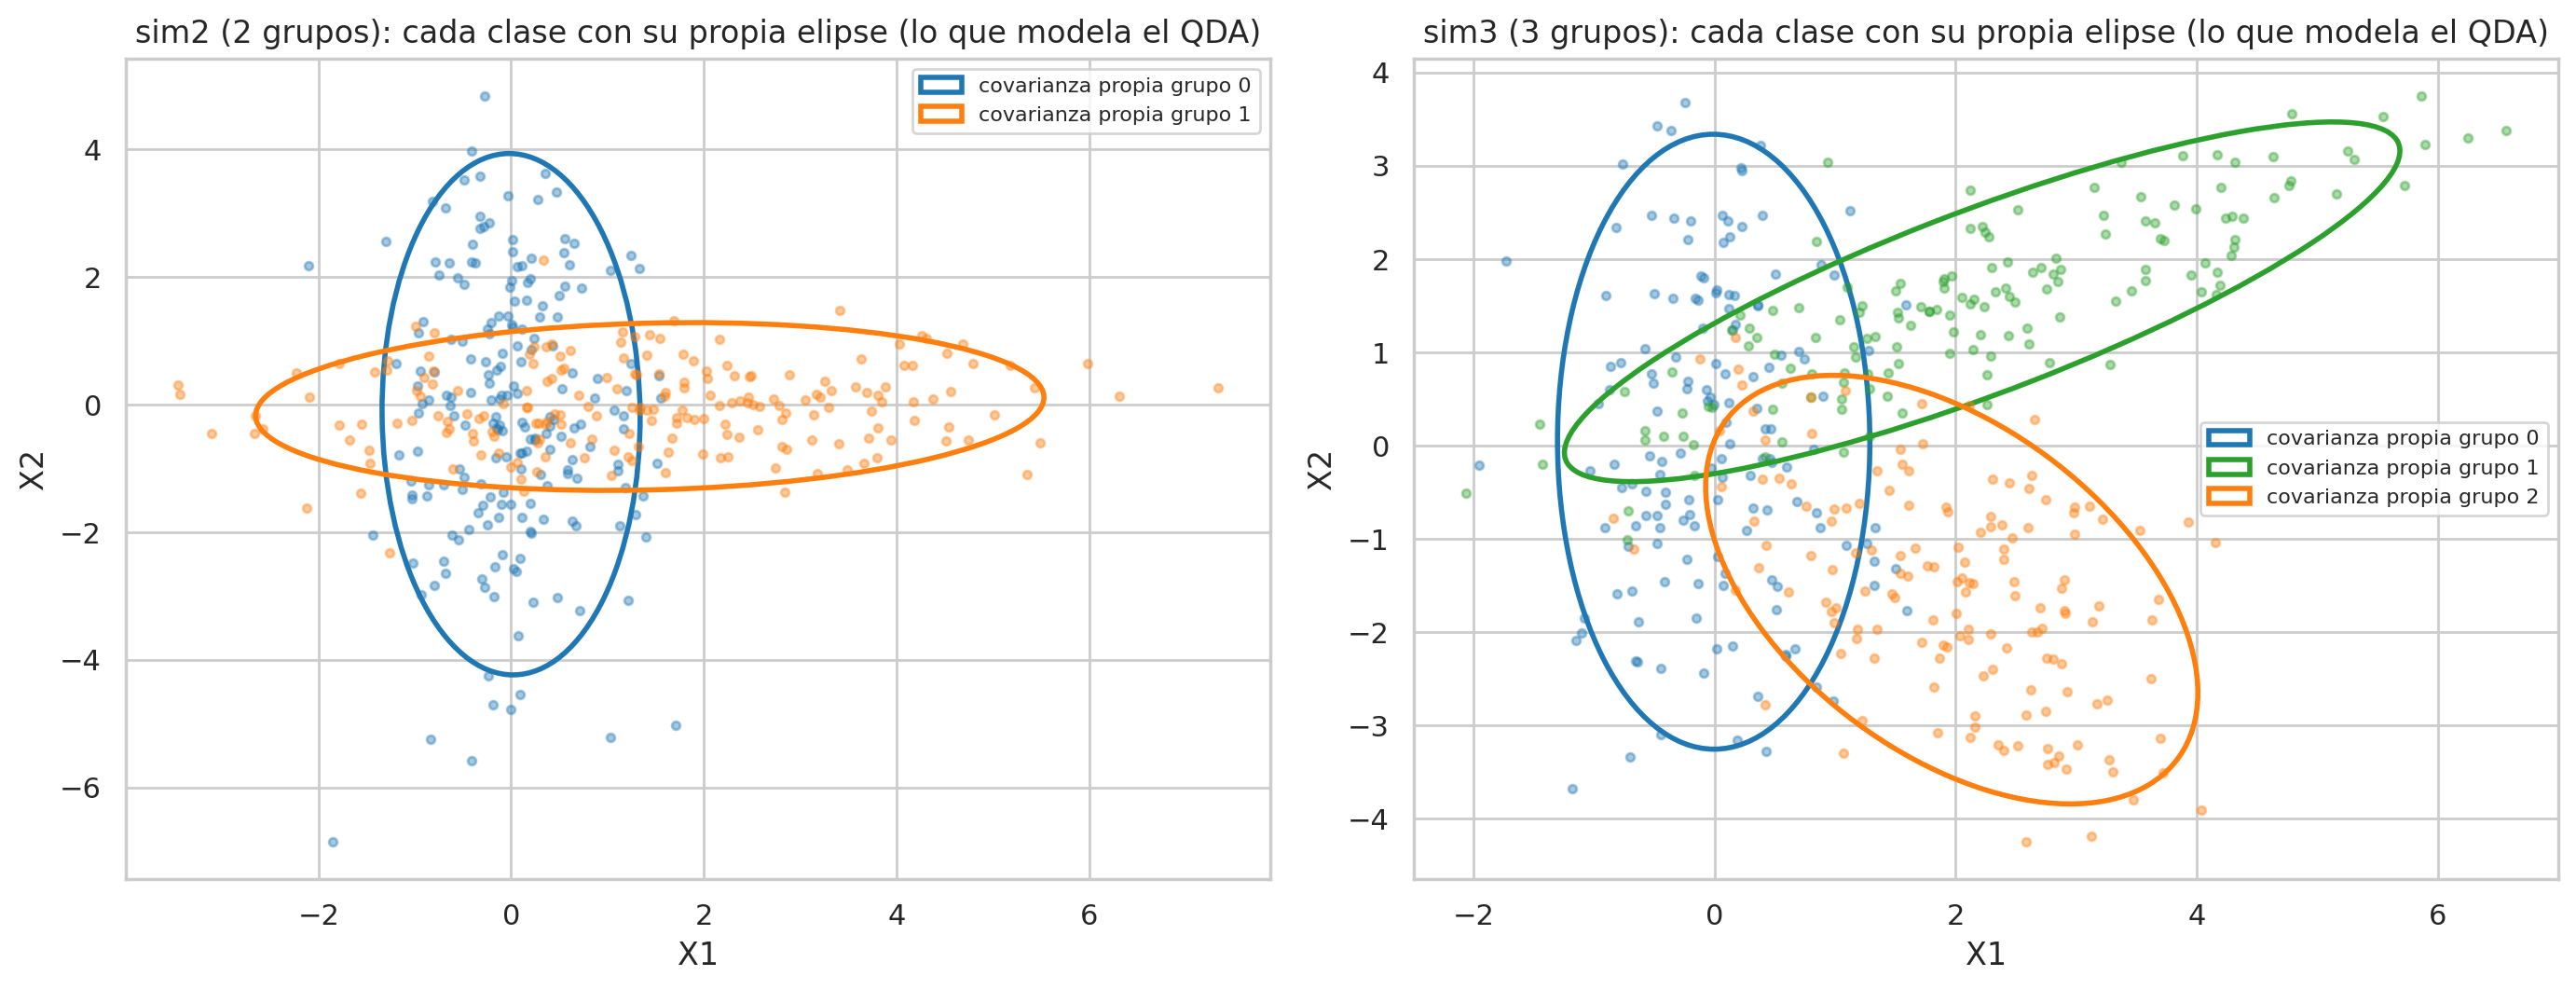

In [12]:
def dibujar_elipse(media, cov, ax, color, n_std=2.0, ls='-', lw=2, label=None):
    vals, vecs = np.linalg.eigh(cov)
    orden = vals.argsort()[::-1]; vals, vecs = vals[orden], vecs[:, orden]
    angulo = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w, h = 2 * n_std * np.sqrt(vals)
    ax.add_patch(Ellipse(media, w, h, angle=angulo, edgecolor=color, fc='none', lw=lw, ls=ls, label=label))

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for datos, a, cols, tit in [(sim2, ax[0], ['tab:blue', 'tab:orange'], 'sim2 (2 grupos)'),
                            (sim3, ax[1], ['tab:blue', 'tab:green', 'tab:orange'], 'sim3 (3 grupos)')]:
    for c, col in zip(sorted(datos['target'].unique()), cols):
        d = datos[datos['target'] == c][['X1', 'X2']].values
        a.scatter(d[:, 0], d[:, 1], s=10, alpha=.4, color=col)
        dibujar_elipse(d.mean(0), np.cov(d.T), a, col, label=f'covarianza propia grupo {c}')
    a.set_title(f'{tit}: cada clase con su propia elipse (lo que modela el QDA)')
    a.legend(fontsize=8); a.set_xlabel('X1'); a.set_ylabel('X2')
plt.tight_layout(); plt.show()

A diferencia del cuaderno anterior (donde dibujábamos una elipse **común** impuesta por el LDA), aquí cada grupo conserva **su propia elipse**: orientaciones y tamaños distintos. Eso es **exactamente** lo que el QDA usa para clasificar, y por eso su frontera podrá "abrazar" la forma de cada nube.

# <font color="steelblue">2. Análisis discriminante regularizado (RDA)</font>

El QDA es flexible pero "caro" en parámetros; el LDA es rígido pero estable. La **regularización** permite movernos **entre ambos** mediante un "dial" que **encoge** las covarianzas hacia formas más simples, reduciendo la **varianza** del modelo a cambio de algo de **sesgo** (el mismo compromiso que en *Ridge*/*Lasso*). Hay dos casos:

* **Caso lineal (`shrinkage` en LDA).** Solo con los *solvers* `'lsqr'` o `'eigen'`. Toma valores en $[0,1]$: con **0** es el LDA habitual y, al aumentar, **encoge** la matriz de covarianzas común hacia una diagonal (esferas), estabilizándola cuando hay pocas muestras o variables muy correlacionadas. La opción `'auto'` la fija automáticamente (lema de Ledoit–Wolf).
* **Caso cuadrático (`reg_param` en QDA).** Toma valores en $[0,1]$: con **0** es el QDA habitual y con **1** lleva cada $\Sigma_k$ hacia una **matriz diagonal** ($\Sigma_k \to (1-\lambda)\Sigma_k + \lambda\, I$). Regularizar aquí evita que una clase con pocos datos produzca una covarianza inestable.

Conviene verlo como un **espectro de flexibilidad**:
* **LDA** (una sola forma, máximo sesgo / mínima varianza)  
* **RDA** (intermedio)
* **QDA** (una forma por clase, mínimo sesgo / máxima varianza).

El valor óptimo de regularización se busca por **validación cruzada**

# <font color="steelblue">3. QDA y RDA en scikit-learn</font>

La clase es **`sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis`**. A diferencia del LDA, **no es una proyección lineal**: modela una elipse (covarianza) por clase y produce fronteras curvas, por lo que **no tiene `transform`, ni `coef_`, ni funciones canónicas**. Su interfaz es la de un clasificador puro.

### <font color="steelblue">Parámetros del constructor</font>

* **`priors`** `array (n_classes,)`, def. `None` — **probabilidades a priori** de cada clase. Por defecto se estiman de las frecuencias del entrenamiento; **igualarlas** (`1/K`) **compensa el desbalanceo**, igual que en LDA (el QDA tampoco tiene `class_weight`). Mueven el umbral de decisión hacia la clase minoritaria.
* **`reg_param`** `float ∈ [0, 1]`, def. `0.0` — **regularización de la covarianza de cada clase**. Contrae cada $\Sigma_k$ hacia una identidad escalada:
  $$\Sigma_k \;\leftarrow\; (1-\texttt{reg\_param})\,\Sigma_k \;+\; \texttt{reg\_param}\cdot I.$$
  Es el **dial sesgo–varianza** del QDA: con `0.0` es QDA puro (elipses libres); al subirlo, las elipses se **redondean** hacia esferas y la frontera se suaviza (acercándose al comportamiento del LDA/diagonal). Sirve para **estabilizar** la estimación y **evitar la singularidad** de $\Sigma_k$ cuando hay **pocas muestras** o **muchas variables**. Es el hiperparámetro que se optimiza por validación cruzada.
* **`store_covariance`** `bool`, def. `False` — si `True`, calcula y guarda explícitamente las **matrices de covarianza por clase** en `covariance_`. Por defecto no se almacenan (el modelo trabaja internamente con `rotations_`/`scalings_`, que son más compactos).
* **`tol`** `float`, def. `1e-4` — umbral para considerar que la covarianza de una clase es **deficiente de rango** (variables colineales) tras aplicar la regularización; actúa como control numérico y de aviso.

### <font color="steelblue">Atributos tras ajustar</font>

* **`means_`** `(n_clases, n_features)` — **centroides** (media de cada clase).
* **`priors_`** `(n_clases,)` — probabilidades a priori **efectivamente usadas** (las de `priors` o las estimadas).
* **`rotations_`** — **lista** (una por clase) con la **orientación** de la elipse de cada grupo: las direcciones de sus ejes principales (autovectores de $\Sigma_k$).
* **`scalings_`** — **lista** (una por clase) con la **escala** a lo largo de esos ejes: la varianza en cada dirección principal (autovalores). Junto con `rotations_` reconstruyen cada covarianza, $\Sigma_k = R_k\,\mathrm{diag}(s_k)\,R_k^{\top}$; es decir, **el tamaño y la inclinación de la elipse de cada clase**.
* **`covariance_`** — **lista** de matrices $\Sigma_k$ `(n_features, n_features)`, una por clase (disponible **solo si `store_covariance=True`**). Ojo: a diferencia del LDA, **no** es una única matriz, sino una por grupo.
* **`classes_`** — etiquetas de clase ordenadas (definen el orden de las listas anteriores y de `predict_proba`).
* **`n_features_in_`** / **`feature_names_in_`** — número y nombres de las variables vistas en `fit` (los nombres, si `X` era un `DataFrame`).







### <font color="steelblue">Métodos principales</font>

* **`fit(X, y)`** — ajusta el modelo (estima medias y la covarianza de cada clase).
* **`predict(X)`** — **clase** predicha (la de mayor discriminante $\delta_k$).
* **`predict_proba(X)`** / **`predict_log_proba(X)`** — **probabilidades** posteriores por clase (y su logaritmo).
* **`decision_function(X)`** — **puntuación** por clase (el valor del discriminante, ya cuadrático); en binario, el signo da la clase.
* **`score(X, y)`** — **exactitud** (*accuracy*) media.
* **`get_params()` / `set_params(**kwargs)`** — leer/fijar hiperparámetros (los usan `Pipeline` y `GridSearchCV`).

**Nota:** el QDA **no** proporciona `coef_` ni funciones canónicas (no es una proyección lineal), lo que tendremos en cuenta al seleccionar variables: al no haber coeficientes que ordenar, la selección debe hacerse por **envoltura** (probando subconjuntos y validando, p. ej. con `SequentialFeatureSelector` o RFE sobre otro estimador), no leyendo importancias del propio modelo.



# <font color="steelblue">4. Discriminante combinado con otros algoritmos</font>

El LDA tiene una segunda vida como **reductor de dimensión supervisado**: su método `transform` proyecta los datos sobre las funciones canónicas (las direcciones que más separan las clases). Esas pocas variables canónicas pueden **alimentar a otro clasificador**, combinando la capacidad del LDA para resumir la separación con la potencia de otro algoritmo. Es una estrategia útil cuando hay muchas variables y se quiere reducir ruido antes de clasificar.

# <font color="steelblue">5. Ejemplos de juguete: LDA vs QDA</font>

Ajustamos LDA y QDA a `sim2` y `sim3` (con el mismo preprocesado y partición) y comparamos sus **regiones de decisión**. Esperamos ver fronteras **rectas** en el LDA y **curvas** en el QDA.



## <font color="steelblue">Dos grupos (sim2)</font>

Comenzamos con el preprocesado de los datos:

In [13]:
# Preprocesado
strain_raw, stest_raw = split_sample(sim2, 'target', 0.3, 123, True)
strain, prep = preprocesar_datos(strain_raw, 'target')
stest,  _    = preprocesar_datos(stest_raw,  'target', prep)
xtrain, ytrain = strain.drop('target', axis=1), strain['target']
xtest,  ytest  = stest.drop('target', axis=1),  stest['target']

Estratificando por 'target'.
  Entrenamiento: 280 muestras | Test: 120 muestras


Entrenamiento de los modeleos LDA, QDA, y representación gráfica de las fronteras de decisión en ambos casos.

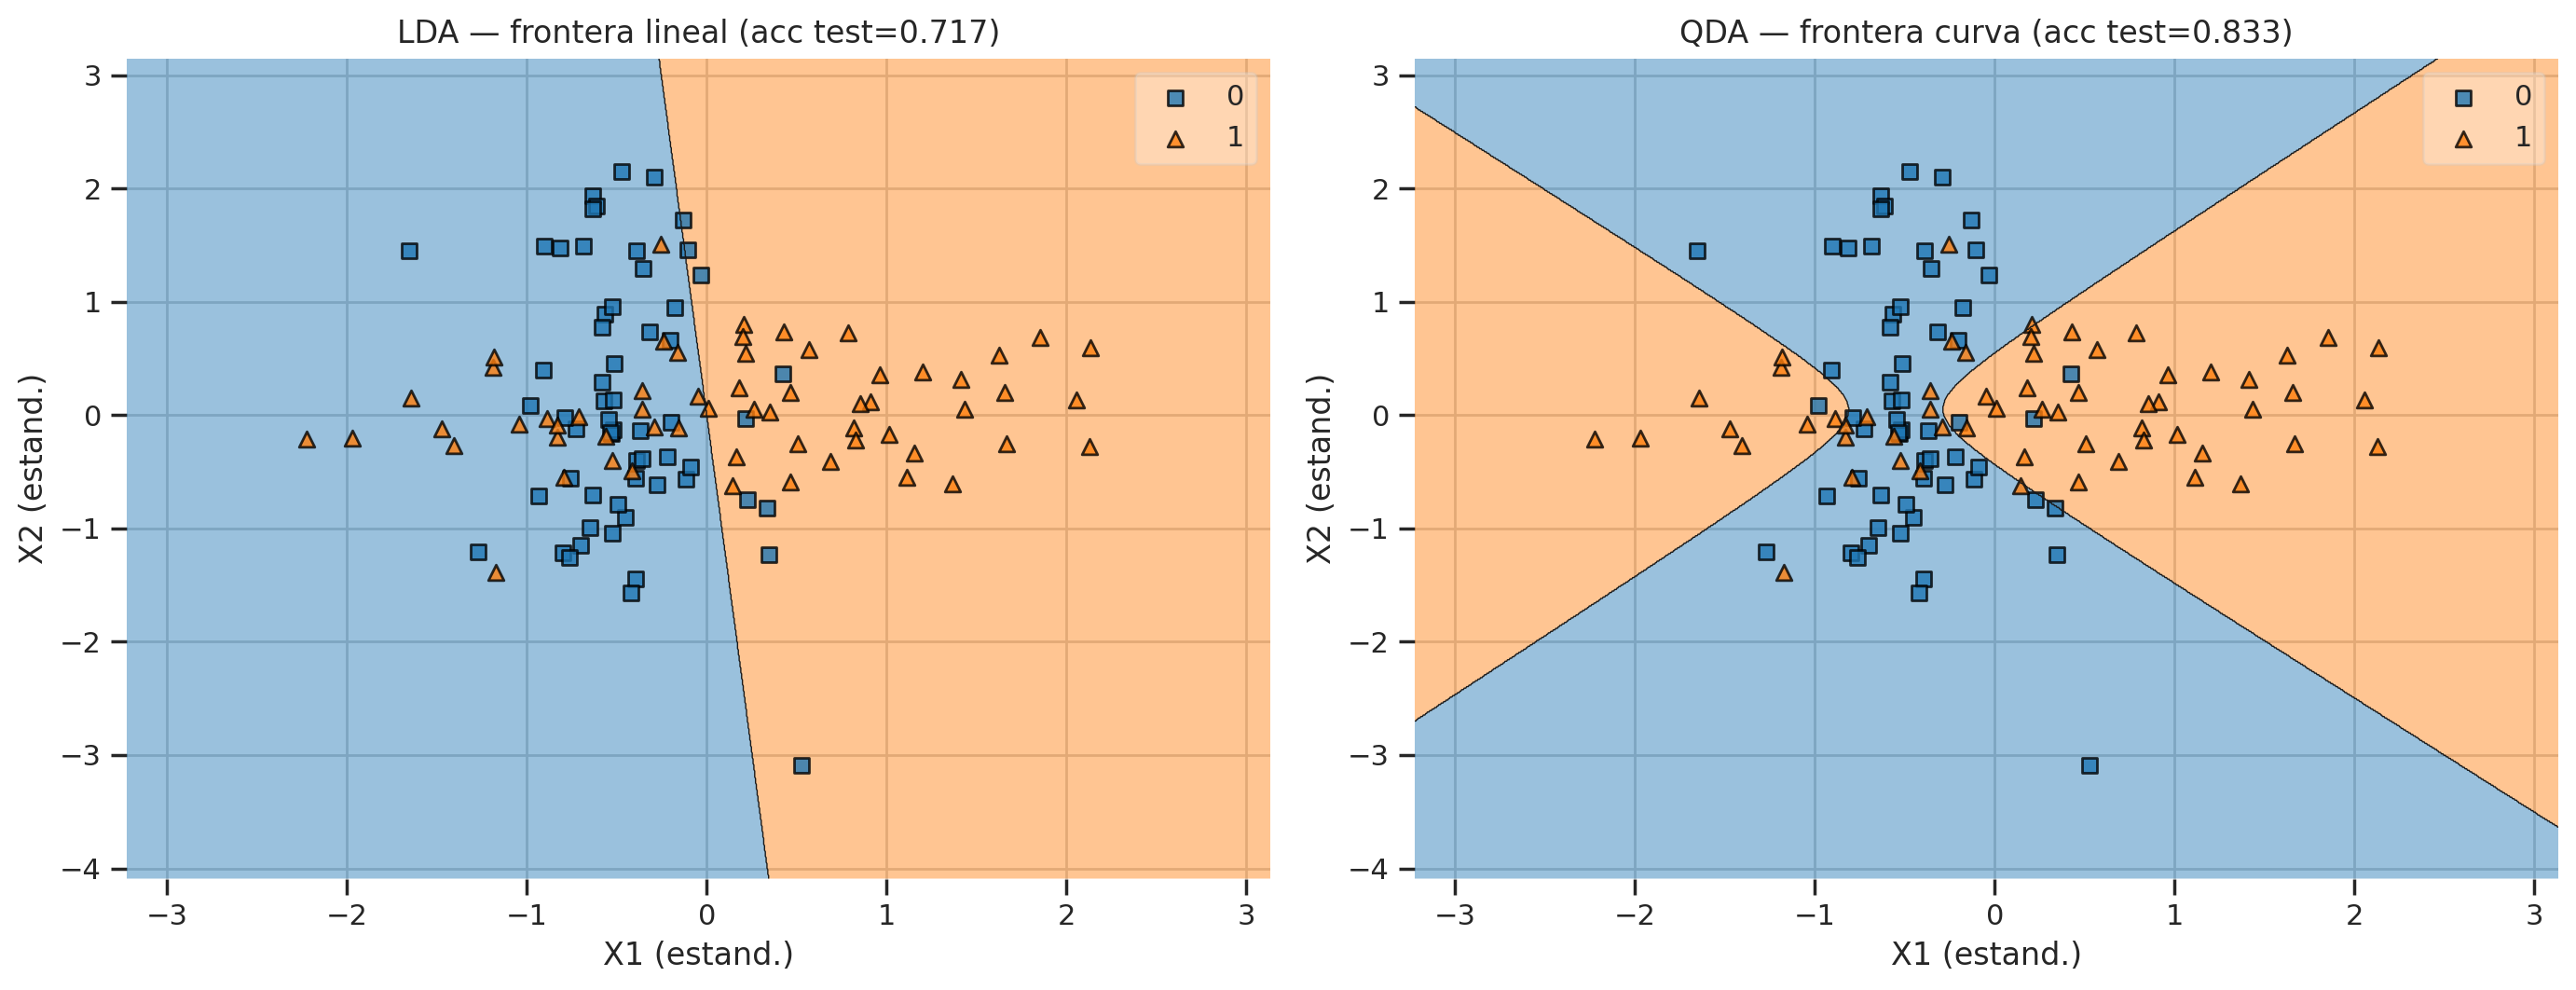

In [14]:
# LDA
lda = LDA().fit(xtrain, ytrain)
# QDA
qda = QDA().fit(xtrain, ytrain)
# Representación de las regiones de decisión
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
plot_decision_regions(X=xtest.values, y=ytest.astype(int).values, clf=lda, ax=ax[0])
ax[0].set_title(f'LDA — frontera lineal (acc test={lda.score(xtest, ytest):.3f})')
plot_decision_regions(X=xtest.values, y=ytest.astype(int).values, clf=qda, ax=ax[1])
ax[1].set_title(f'QDA — frontera curva (acc test={qda.score(xtest, ytest):.3f})')
for a in ax: a.set_xlabel('X1 (estand.)'); a.set_ylabel('X2 (estand.)')
plt.tight_layout(); plt.show()

La frontera del **LDA** es una recta que no puede seguir el cruce de las dos nubes; la del **QDA** es **curva** y se adapta a sus formas, recuperando puntos que el LDA clasificaba mal (la exactitud sube de ~0.72 a ~0.83).

Evaluamos el modelo entrenado analizando la matriz de confusión del modelo QDA.

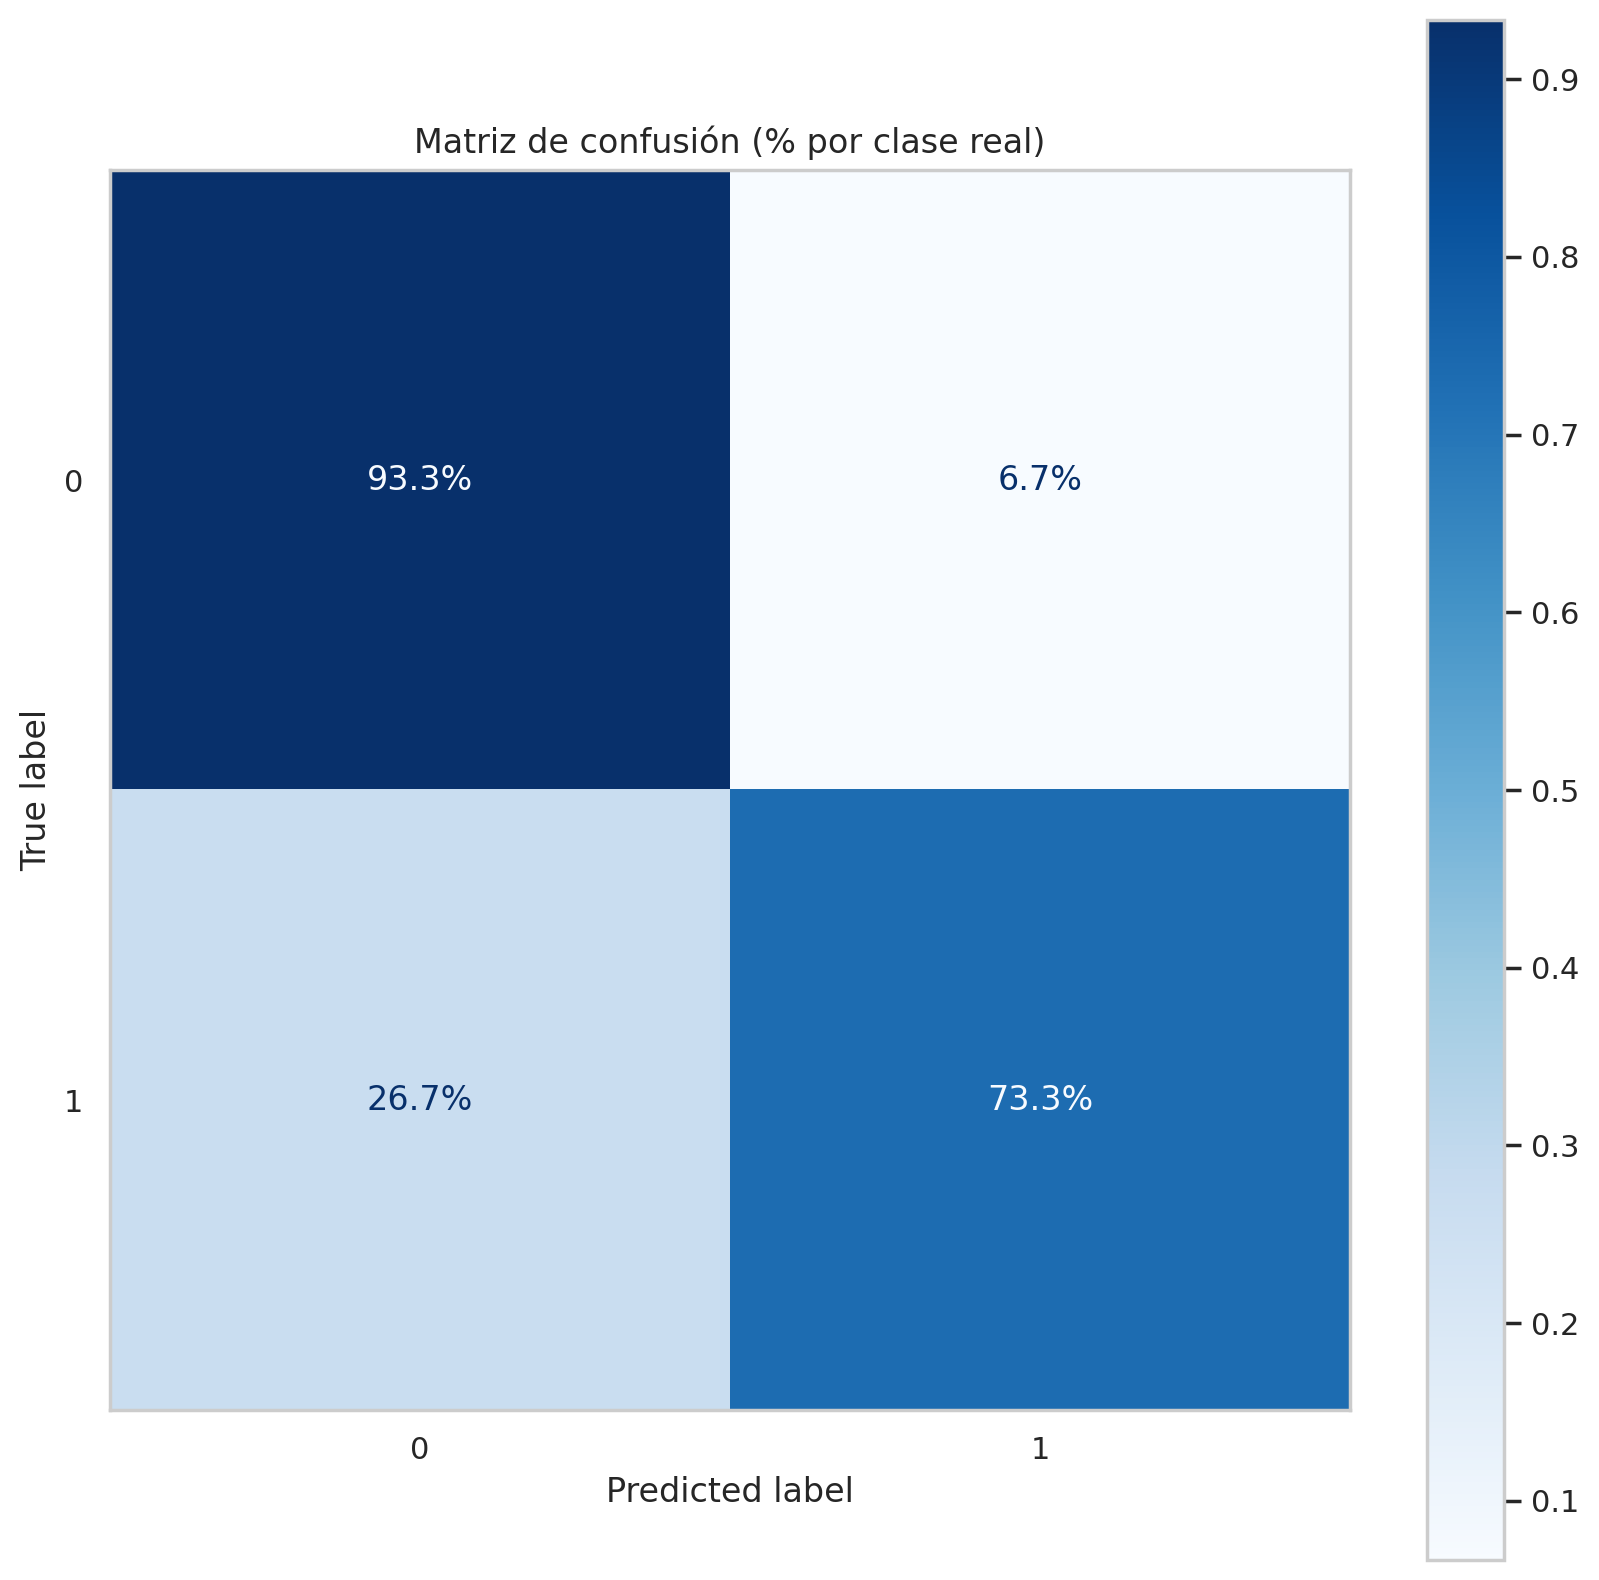

In [15]:
matriz_confusion(qda, xtest, ytest);

El error de clasificación como 1 los datos originales clasificados como cero se sitúa en el 26.7%. Veamos que ocurre con el análsisis de validación de ambos modelos

In [16]:
val_qda = validar_modelo(qda, xtrain, ytrain, 'accuracy', 10)
val_lda = validar_modelo(lda, xtrain, ytrain, 'accuracy', 10)

Validacion cruzada (10 folds, score=accuracy): media = 0.793 +/- 0.080
Validacion cruzada (10 folds, score=accuracy): media = 0.746 +/- 0.111


Podemos ver como el modelo QDA clasifica mejor  (accuracy más grande con grupos equilibrados), y de forma más precisa (desviación típica más pequeña).

Veamos la curva de aprendizaje asociada al modleo cuadrático

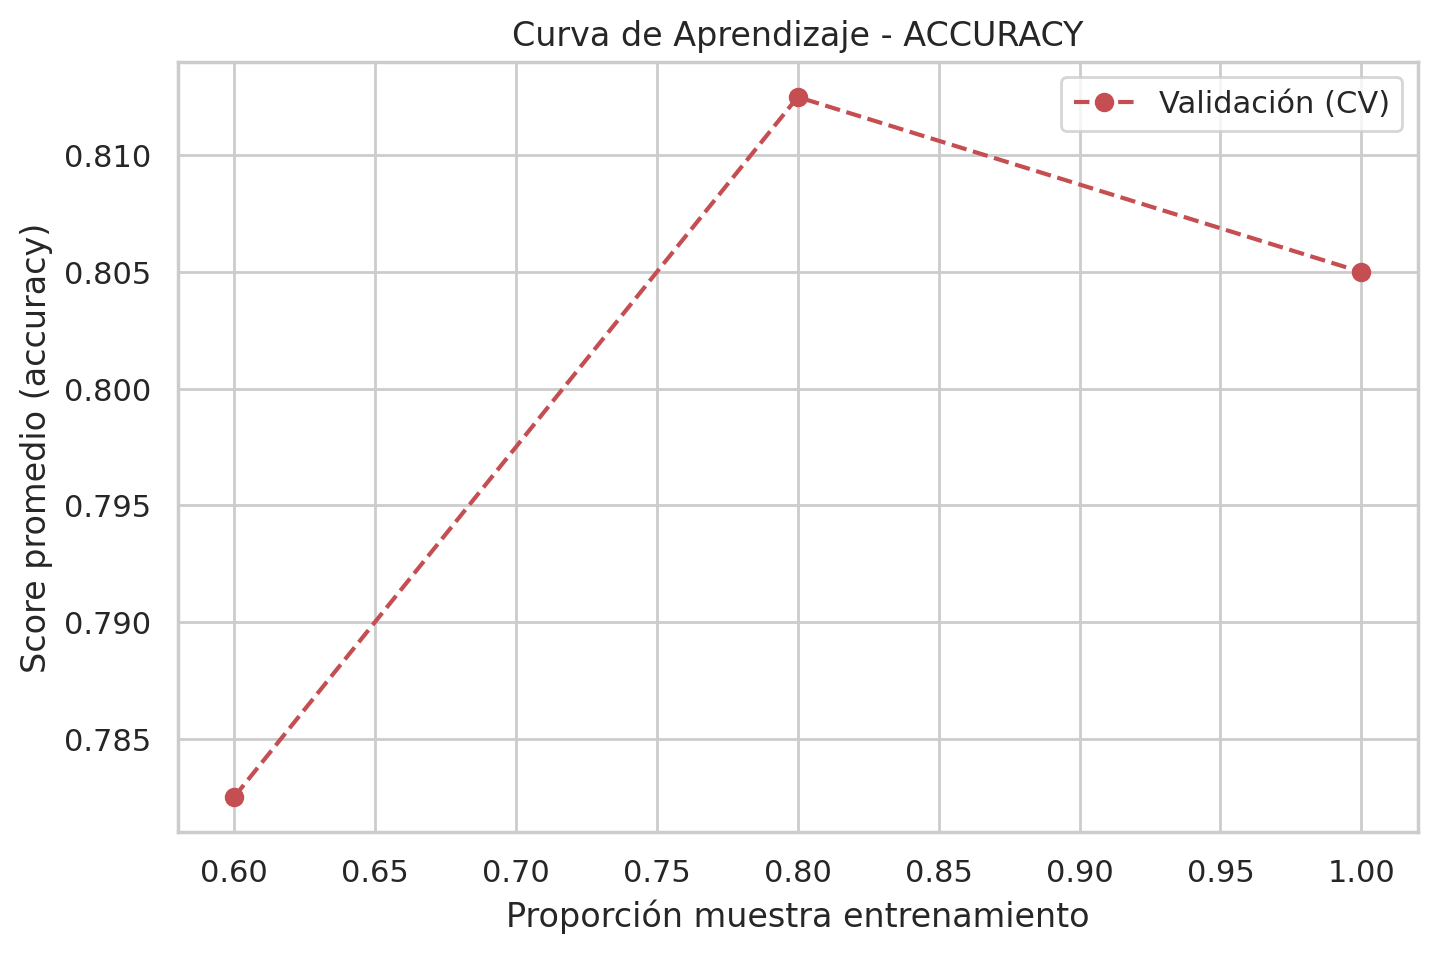

In [17]:
datos_pp, _ = preprocesar_datos(sim2, 'target')
X = datos_pp.drop('target', axis=1)
y = datos_pp['target']
curva_aprendizaje(qda, X, y, 'accuracy', 10);

La validación cruzada confirma la mejora del QDA frente al LDA (de ~0.73 a ~0.82 de exactitud media) de forma **estable**. La curva de aprendizaje muestra que el QDA aprovecha mejor la información disponible al no estar limitado a una frontera recta.

## <font color="steelblue">Tres grupos (sim3)</font>

Prodemos ahora con el ejemplo con tres grupos:

Estratificando por 'target'.
  Entrenamiento: 315 muestras | Test: 135 muestras


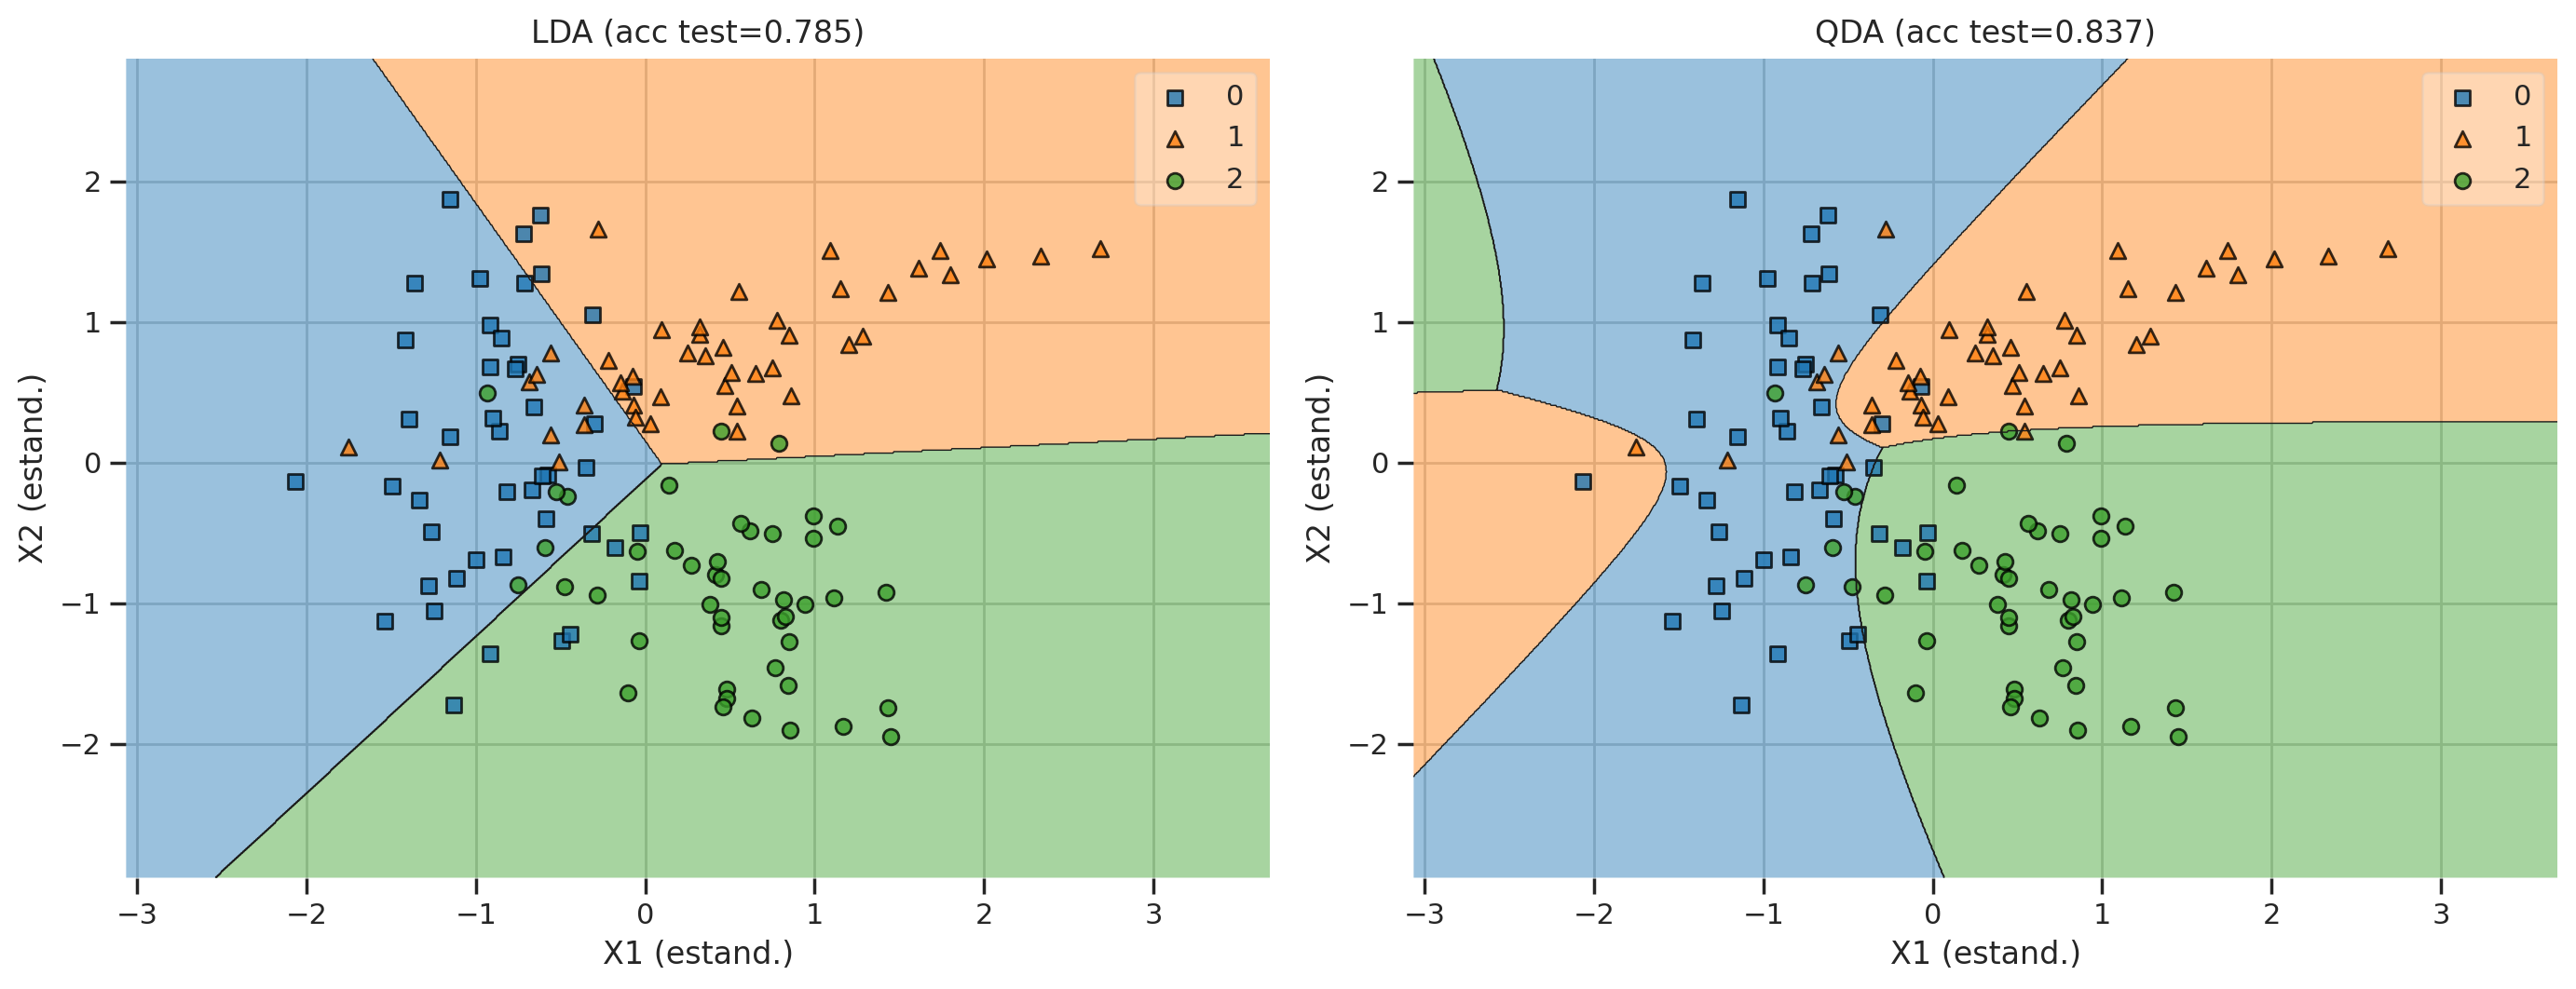

In [19]:
strain_raw, stest_raw = split_sample(sim3, 'target', 0.3, 123, True)
strain, prep = preprocesar_datos(strain_raw, 'target')
stest,  _    = preprocesar_datos(stest_raw,  'target', prep)
xtrain, ytrain = strain.drop('target', axis=1), strain['target']
xtest,  ytest  = stest.drop('target', axis=1),  stest['target']

lda3 = LDA().fit(xtrain, ytrain); qda3 = QDA().fit(xtrain, ytrain)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
plot_decision_regions(X=xtest.values, y=ytest.astype(int).values, clf=lda3, ax=ax[0])
ax[0].set_title(f'LDA (acc test={lda3.score(xtest, ytest):.3f})')
plot_decision_regions(X=xtest.values, y=ytest.astype(int).values, clf=qda3, ax=ax[1])
ax[1].set_title(f'QDA (acc test={qda3.score(xtest, ytest):.3f})')
for a in ax: a.set_xlabel('X1 (estand.)'); a.set_ylabel('X2 (estand.)')
plt.tight_layout(); plt.show()

Con tres grupos, el QDA dibuja **fronteras curvas** entre cada par de clases, ajustándose mejor a las regiones solapadas.

Evaluamos el modelo considerado.

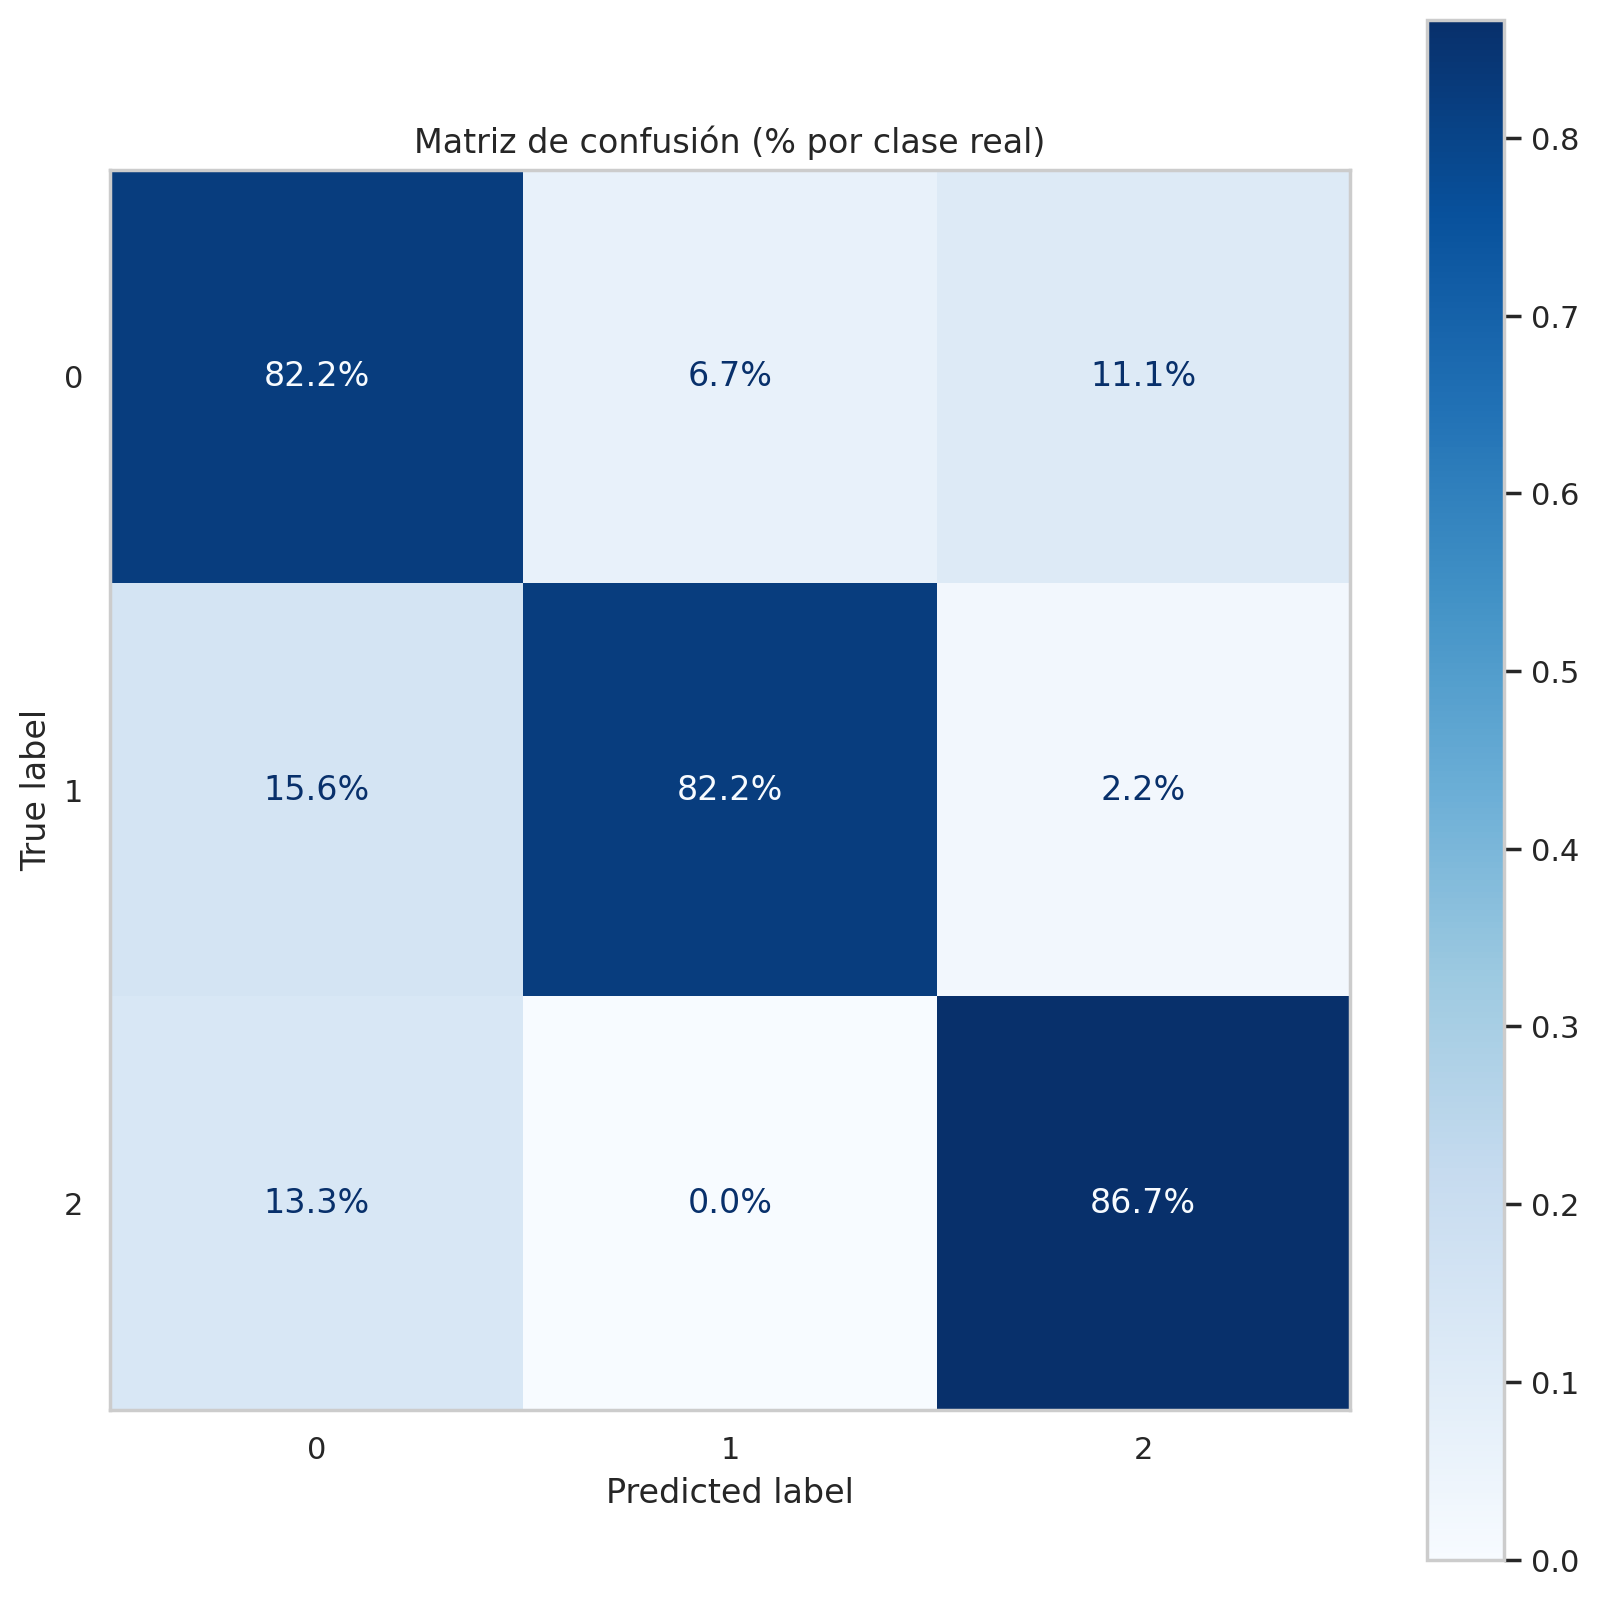

In [20]:
matriz_confusion(qda3, xtest, ytest);

In [21]:
val_qda3 = validar_modelo(qda3, xtrain, ytrain, 'accuracy', 10)

Validacion cruzada (10 folds, score=accuracy): media = 0.839 +/- 0.064


El QDA mejora ligeramente al LDA (de ~0.81 a ~0.84). En los dos juguetes la conclusión es la misma: cuando las clases tienen **formas distintas**, la frontera curva del QDA **gana**.

# <font color="steelblue">6. Aplicaciones reales</font>

Aplicamos LDA y QDA a los dos conjuntos reales del cuaderno anterior, en los que **no se cumplían** las hipótesis del LDA. Veremos que el QDA ayuda en uno (water) pero no en otro (abalone): la flexibilidad no siempre mejora.



## <font color="steelblue">6.1. Potabilidad del agua (2 grupos)</font>

Recordatorio del banco: **3.276 muestras** de agua descritas por **9 variables fisicoquímicas** (pH, dureza, sólidos disueltos, cloraminas, sulfatos, conductividad, carbono orgánico, trihalometanos y turbidez), con target **potable (1) / no potable (0)** y **desbalanceo** (~61 %/39 %). En el cuaderno de LDA el modelo lineal apenas detectaba la clase potable; veamos si el QDA lo mejora. Para el entrenaiento del modelo consideramos los tamaños a priori de cada uno de los grupos.

In [29]:
# Carga, preprocesado
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/water_clean.csv'
water = pd.read_csv(url, index_col=0); water['Potability'] = water['Potability'].astype('category')
strain_raw, stest_raw = split_sample(water, 'Potability', 0.2, 123, True)
strain, prep = preprocesar_datos(strain_raw, 'Potability')
stest,  _    = preprocesar_datos(stest_raw,  'Potability', prep)
xtrain, ytrain = strain.drop('Potability', axis=1), strain['Potability']
xtest,  ytest  = stest.drop('Potability', axis=1),  stest['Potability']
# Frecuencias iniciales en la muestra de entrenamiento
prop_ini = list(ytrain.value_counts()/len(ytrain))
# Entrenamiento de los modelos
lda = LDA(priors=prop_ini).fit(xtrain, ytrain)
qda = QDA(priors=prop_ini).fit(xtrain, ytrain)

Estratificando por 'Potability'.
  Entrenamiento: 2620 muestras | Test: 656 muestras


Obtenemos el informe de clasificación asociada a cada modelo.

In [30]:
# Modelo LDA
reports_clas(lda, xtrain, ytrain, xtest, ytest)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       0.61      1.00      0.76      1598
           1       0.86      0.01      0.01      1022

    accuracy                           0.61      2620
   macro avg       0.73      0.50      0.39      2620
weighted avg       0.71      0.61      0.47      2620


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       1.00      0.01      0.02       256

    accuracy                           0.61       656
   macro avg       0.81      0.51      0.39       656
weighted avg       0.76      0.61      0.47       656



In [31]:
# Modelo QDA
reports_clas(qda, xtrain, ytrain, xtest, ytest)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       0.68      0.90      0.77      1598
           1       0.67      0.34      0.45      1022

    accuracy                           0.68      2620
   macro avg       0.68      0.62      0.61      2620
weighted avg       0.68      0.68      0.65      2620


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       0.70      0.90      0.79       400
           1       0.72      0.39      0.50       256

    accuracy                           0.70       656
   macro avg       0.71      0.64      0.64       656
weighted avg       0.70      0.70      0.68       656



Claramente los resulatdos para el modelo QDA mejoran los resultados del LDA. Pasamos de un f1 de 0.47 para LDA a un 0.68 para QDA. De hecho, podemos ver que el valor de f1 para el grupo 1 aumenta de 0.02 a 0.50 en la muestra de test, lo que es una mejora considerable.

Obtenemos la matriz de confusión para el modelo QDA:

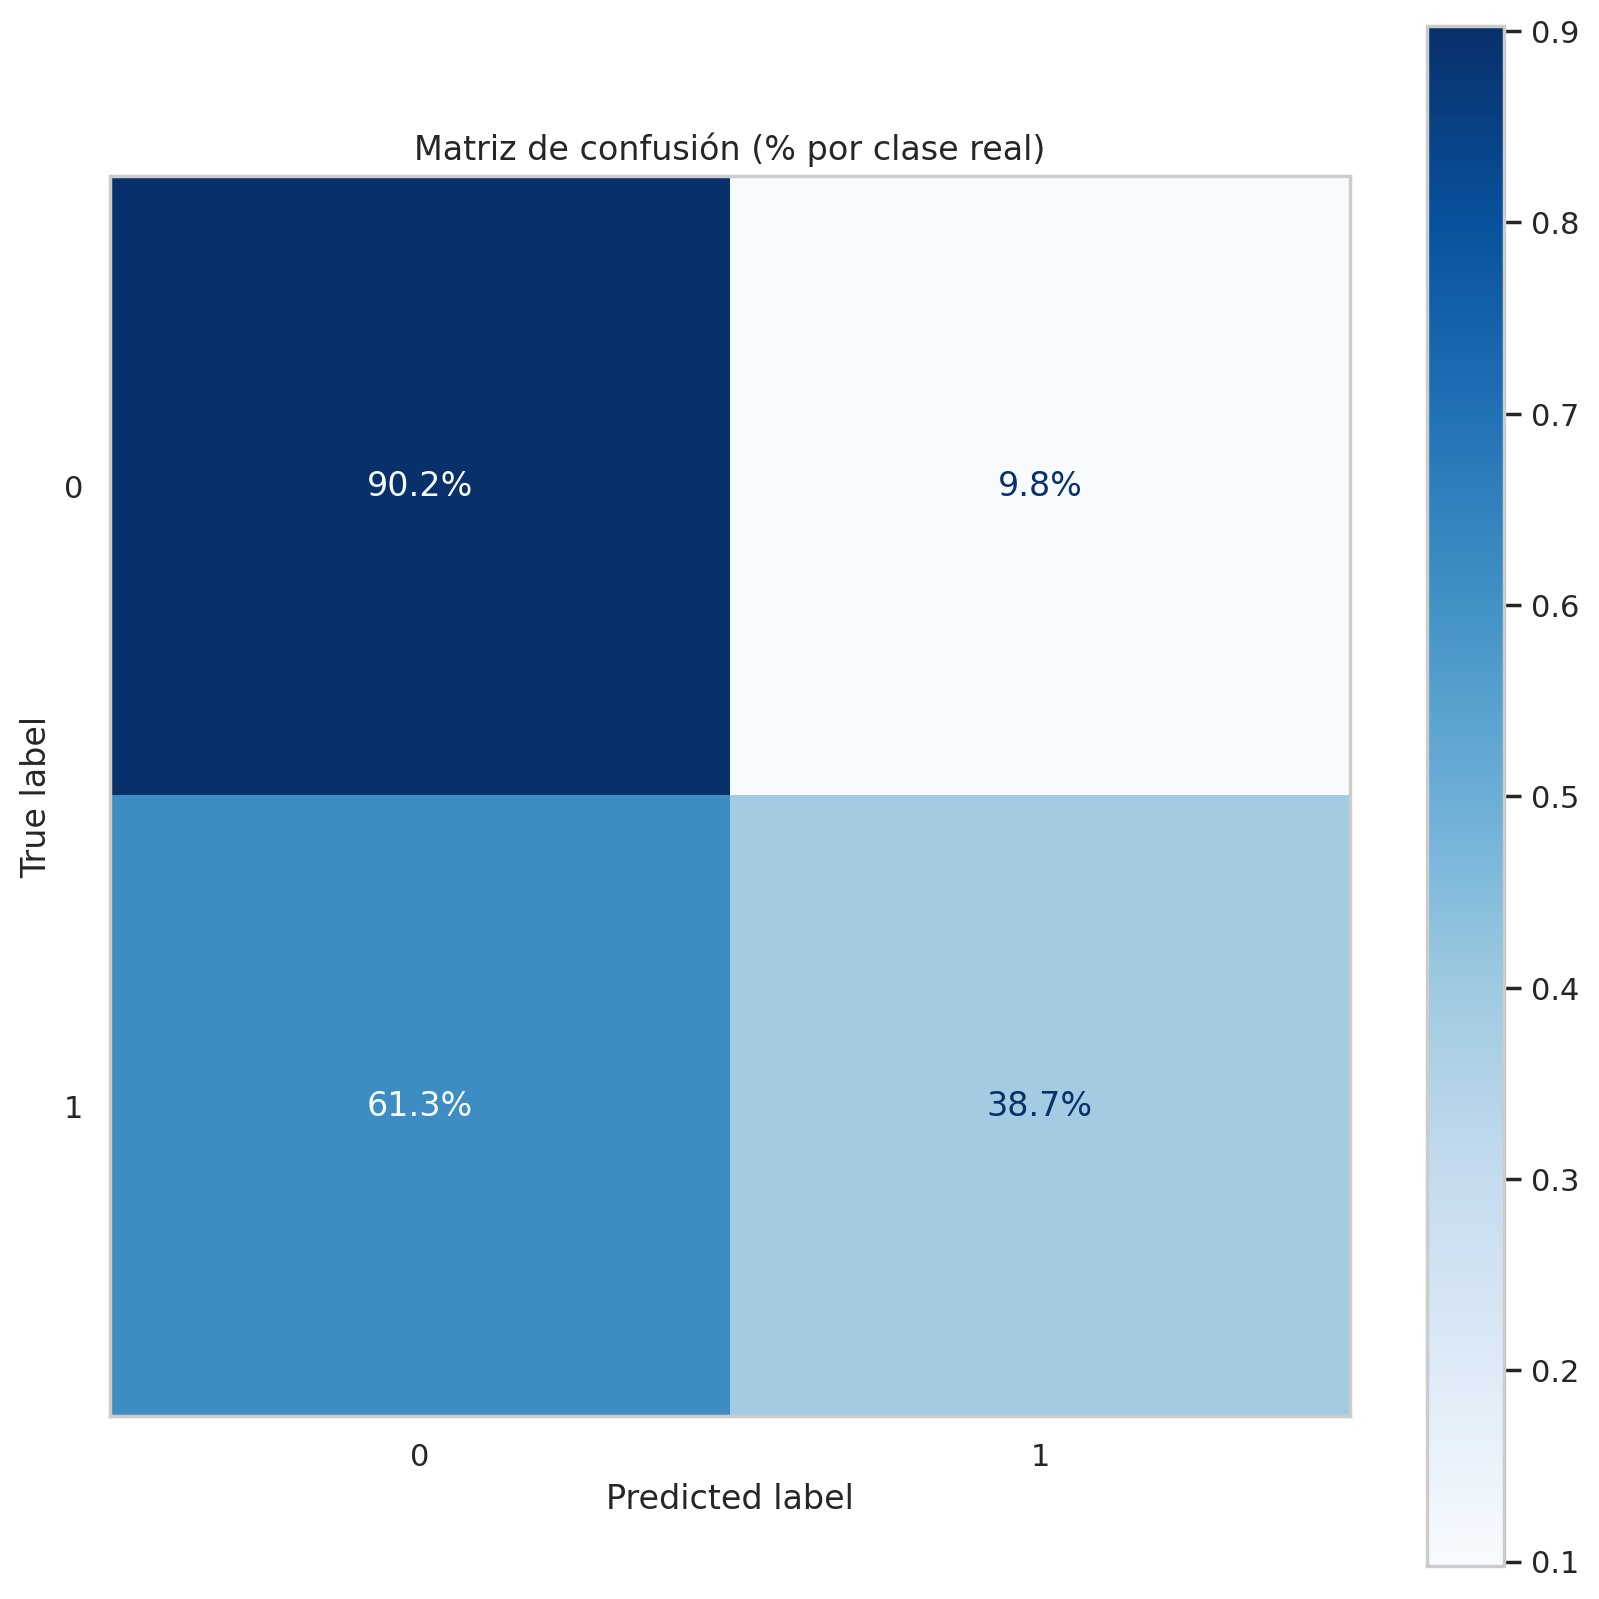

In [32]:
matriz_confusion(qda, xtest, ytest);

Aunque el error de clasificación 1 - 0 es bastante alto (61.3%) hemos conseguido mejorar de froma ostensible los resultados del modelo LDA que viene en al tabla de confusión siguiente:

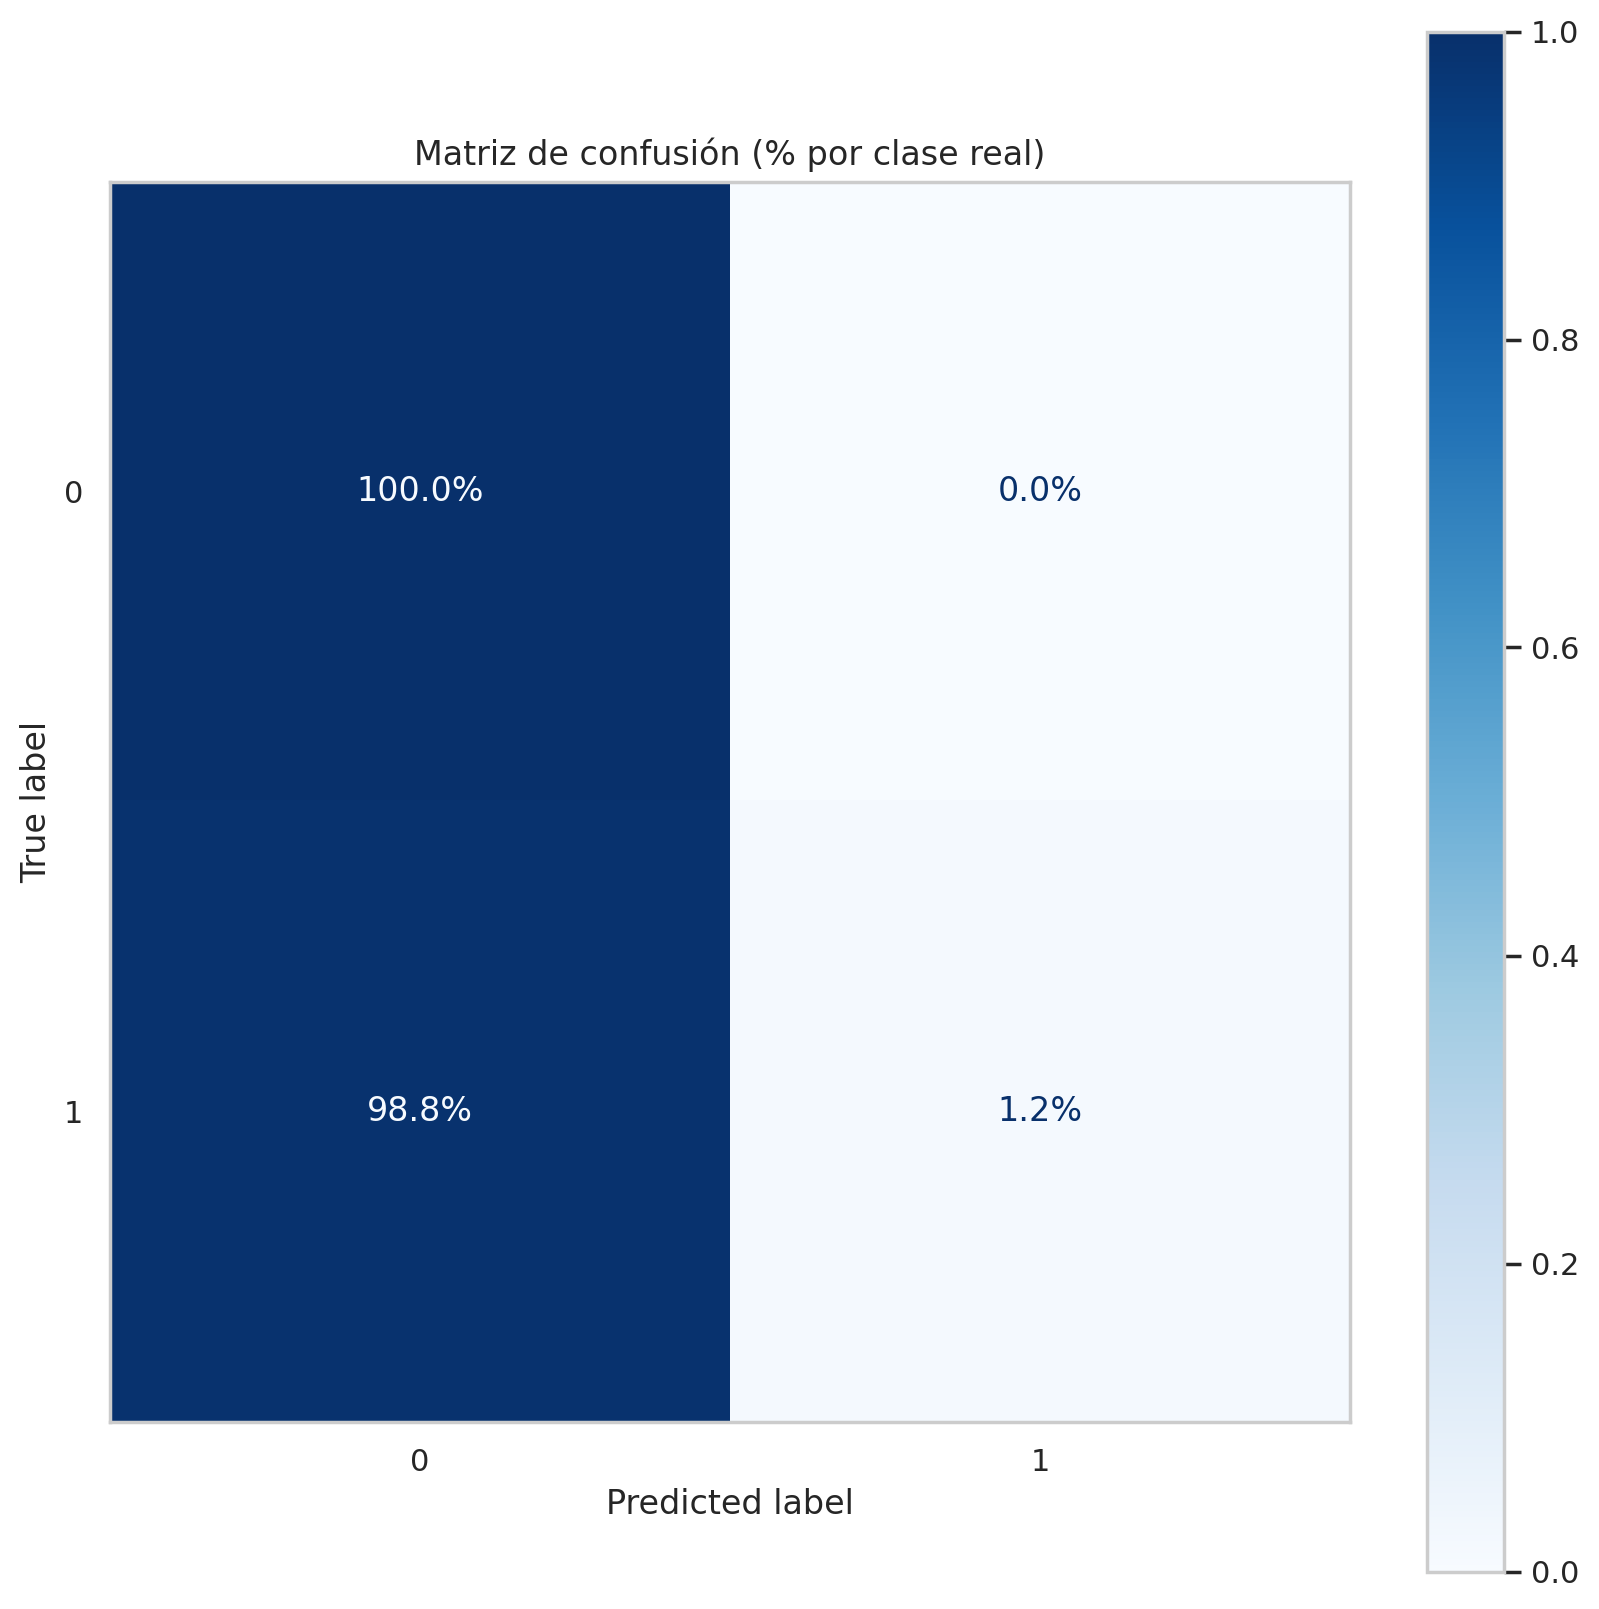

In [33]:
matriz_confusion(lda, xtest, ytest);

Validamos el modelo QDA:

In [35]:
val_qda = validar_modelo(qda, xtrain, ytrain, 'f1_weighted', 10)

Validacion cruzada (10 folds, score=f1_weighted): media = 0.662 +/- 0.024


### <font color="steelblue">6.1.1. Selección de variables y regiones de decisión</font>

El QDA **no** expone `coef_`, así que no podemos usar la RFE de `select_variables` (que necesita coeficientes). Empleamos un método **filtro** independiente del modelo: el **estadístico F de ANOVA** (`f_classif`), que mide cuánto difieren las medias de cada variable entre clases. Tomamos las **2 más relevantes** y dibujamos las regiones del QDA (curvas) frente a las del LDA (rectas).

In [36]:
F, _ = f_classif(xtrain, ytrain)
ranking = pd.Series(F, index=xtrain.columns).sort_values(ascending=False)
print('Ranking de variables (F de ANOVA):'); print(ranking.round(1))
top2 = ranking.index[:2].tolist(); print('\nDos variables más relevantes:', top2)

Ranking de variables (F de ANOVA):
Solids             4.0
Hardness           3.4
Sulfate            2.2
Chloramines        1.5
Organic_carbon     1.4
Trihalomethanes    0.2
Conductivity       0.1
ph                 0.1
Turbidity          0.0
dtype: float64

Dos variables más relevantes: ['Solids', 'Hardness']


Entrenamos el modelo con las dos mejores variables y representamos las regiones de decisión:

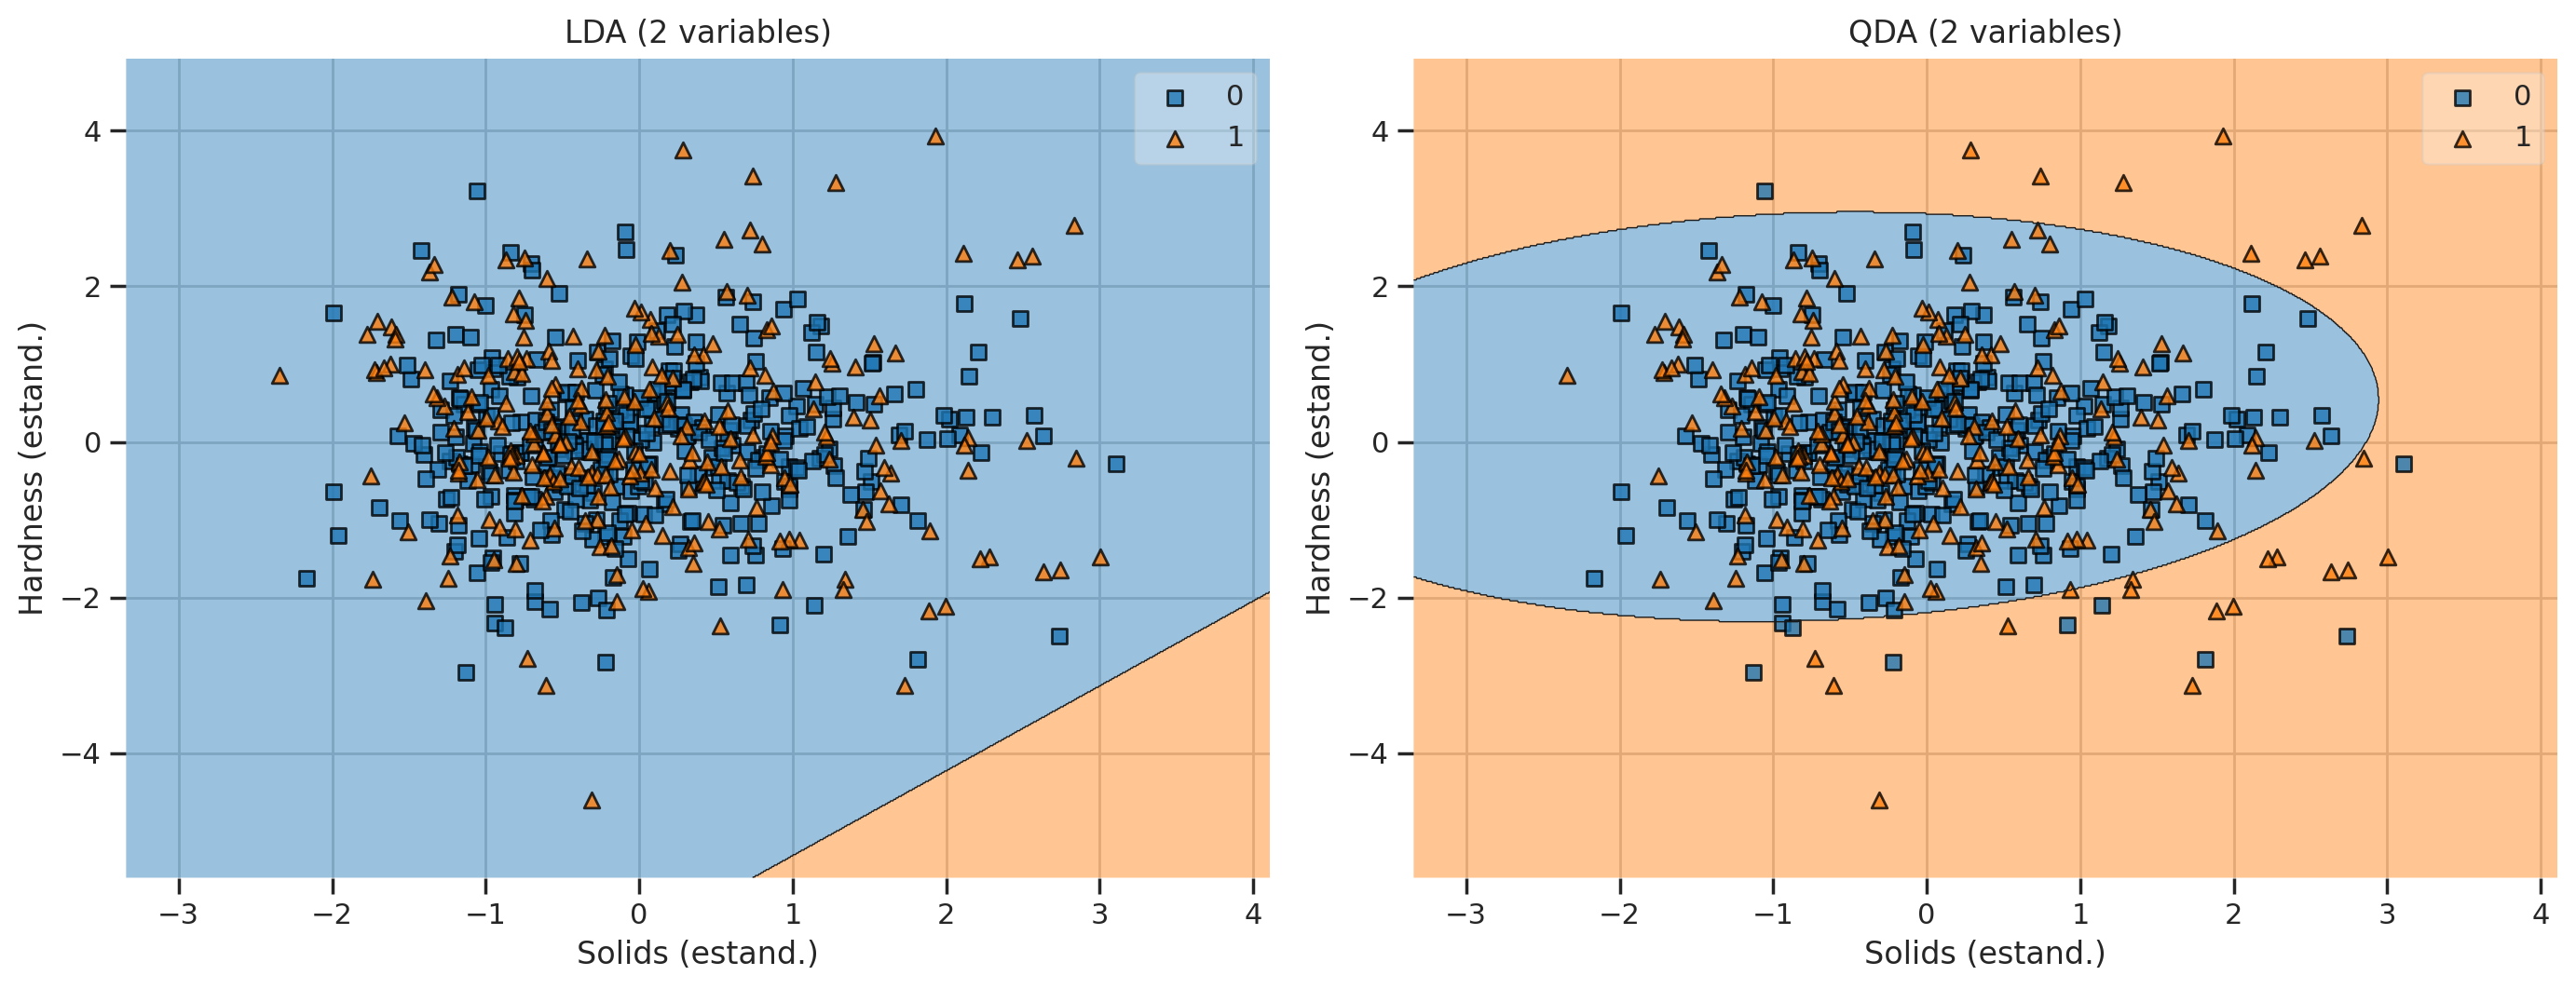

In [37]:
# Entrenamiento con sólo dos variables
lda2 = LDA(priors=prop_ini).fit(xtrain[top2], ytrain)
qda2 = QDA(priors=prop_ini).fit(xtrain[top2], ytrain)
# Representación de las regiones de decisión
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
plot_decision_regions(X=xtest[top2].values, y=ytest.astype(int).values, clf=lda2, ax=ax[0]); ax[0].set_title('LDA (2 variables)')
plot_decision_regions(X=xtest[top2].values, y=ytest.astype(int).values, clf=qda2, ax=ax[1]); ax[1].set_title('QDA (2 variables)')
for a in ax: a.set_xlabel(top2[0] + ' (estand.)'); a.set_ylabel(top2[1] + ' (estand.)')
plt.tight_layout(); plt.show()

Con solo dos variables se aprecia la diferencia de **forma** de las fronteras: el LDA traza una recta y el QDA una curva. Aun así, como las clases del agua están **muy entremezcladas**, ninguna de las dos separa de forma limpia: el QDA ayuda, pero el problema sigue siendo difícil. Deberíamos considerar al menos todas las varaibles con un valor del estadístico F mayor que 1 (5 variables, auqnue no podamos representarlo gráficamente).

### <font color="steelblue">6.1.2. Equilibrado de clases con QDA</font>

Como la clase **potable** es minoritaria, comparamos el QDA base con las otras dos estrategias de equilibrado (las mismas del cuaderno anterior): **SMOTE** (sobremuestreo sintético de la minoría) y **NearMiss** (submuestreo de la mayoría). Recuerda que los remuestreos se aplican **solo al entrenamiento**.

In [38]:
# SMOTE
xtr_sm, ytr_sm = SMOTE(random_state=RNG).fit_resample(xtrain, ytrain)
qda_smote = QDA().fit(xtr_sm, ytr_sm)
# NearMiss
xtr_nm, ytr_nm = NearMiss().fit_resample(xtrain, ytrain)
qda_nm = QDA().fit(xtr_nm, ytr_nm)

print('SMOTE:', ytr_sm.value_counts().to_dict(), '| NearMiss:', ytr_nm.value_counts().to_dict())

SMOTE: {0: 1598, 1: 1598} | NearMiss: {0: 1022, 1: 1022}


Comparamos los informes de clasificación de los nuevos modelos:

In [39]:
reports_clas(qda_smote, xtr_sm, ytr_sm, xtest, ytest)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       0.62      0.71      0.66      1598
           1       0.66      0.57      0.61      1598

    accuracy                           0.64      3196
   macro avg       0.64      0.64      0.64      3196
weighted avg       0.64      0.64      0.64      3196


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       0.73      0.68      0.70       400
           1       0.55      0.62      0.58       256

    accuracy                           0.65       656
   macro avg       0.64      0.65      0.64       656
weighted avg       0.66      0.65      0.66       656



In [40]:
reports_clas(qda_nm, xtr_sm, ytr_sm, xtest, ytest)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       0.56      0.61      0.59      1598
           1       0.57      0.52      0.55      1598

    accuracy                           0.57      3196
   macro avg       0.57      0.57      0.57      3196
weighted avg       0.57      0.57      0.57      3196


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       0.72      0.62      0.67       400
           1       0.51      0.62      0.56       256

    accuracy                           0.62       656
   macro avg       0.62      0.62      0.62       656
weighted avg       0.64      0.62      0.63       656



Los resultados del equilibrio en ambos modelos es bastante similar. De hecho, el modleo con proporciones inicales es solo algo mejor en las métricas consideradas.

Podemos ver ahora las matrices de confusión:

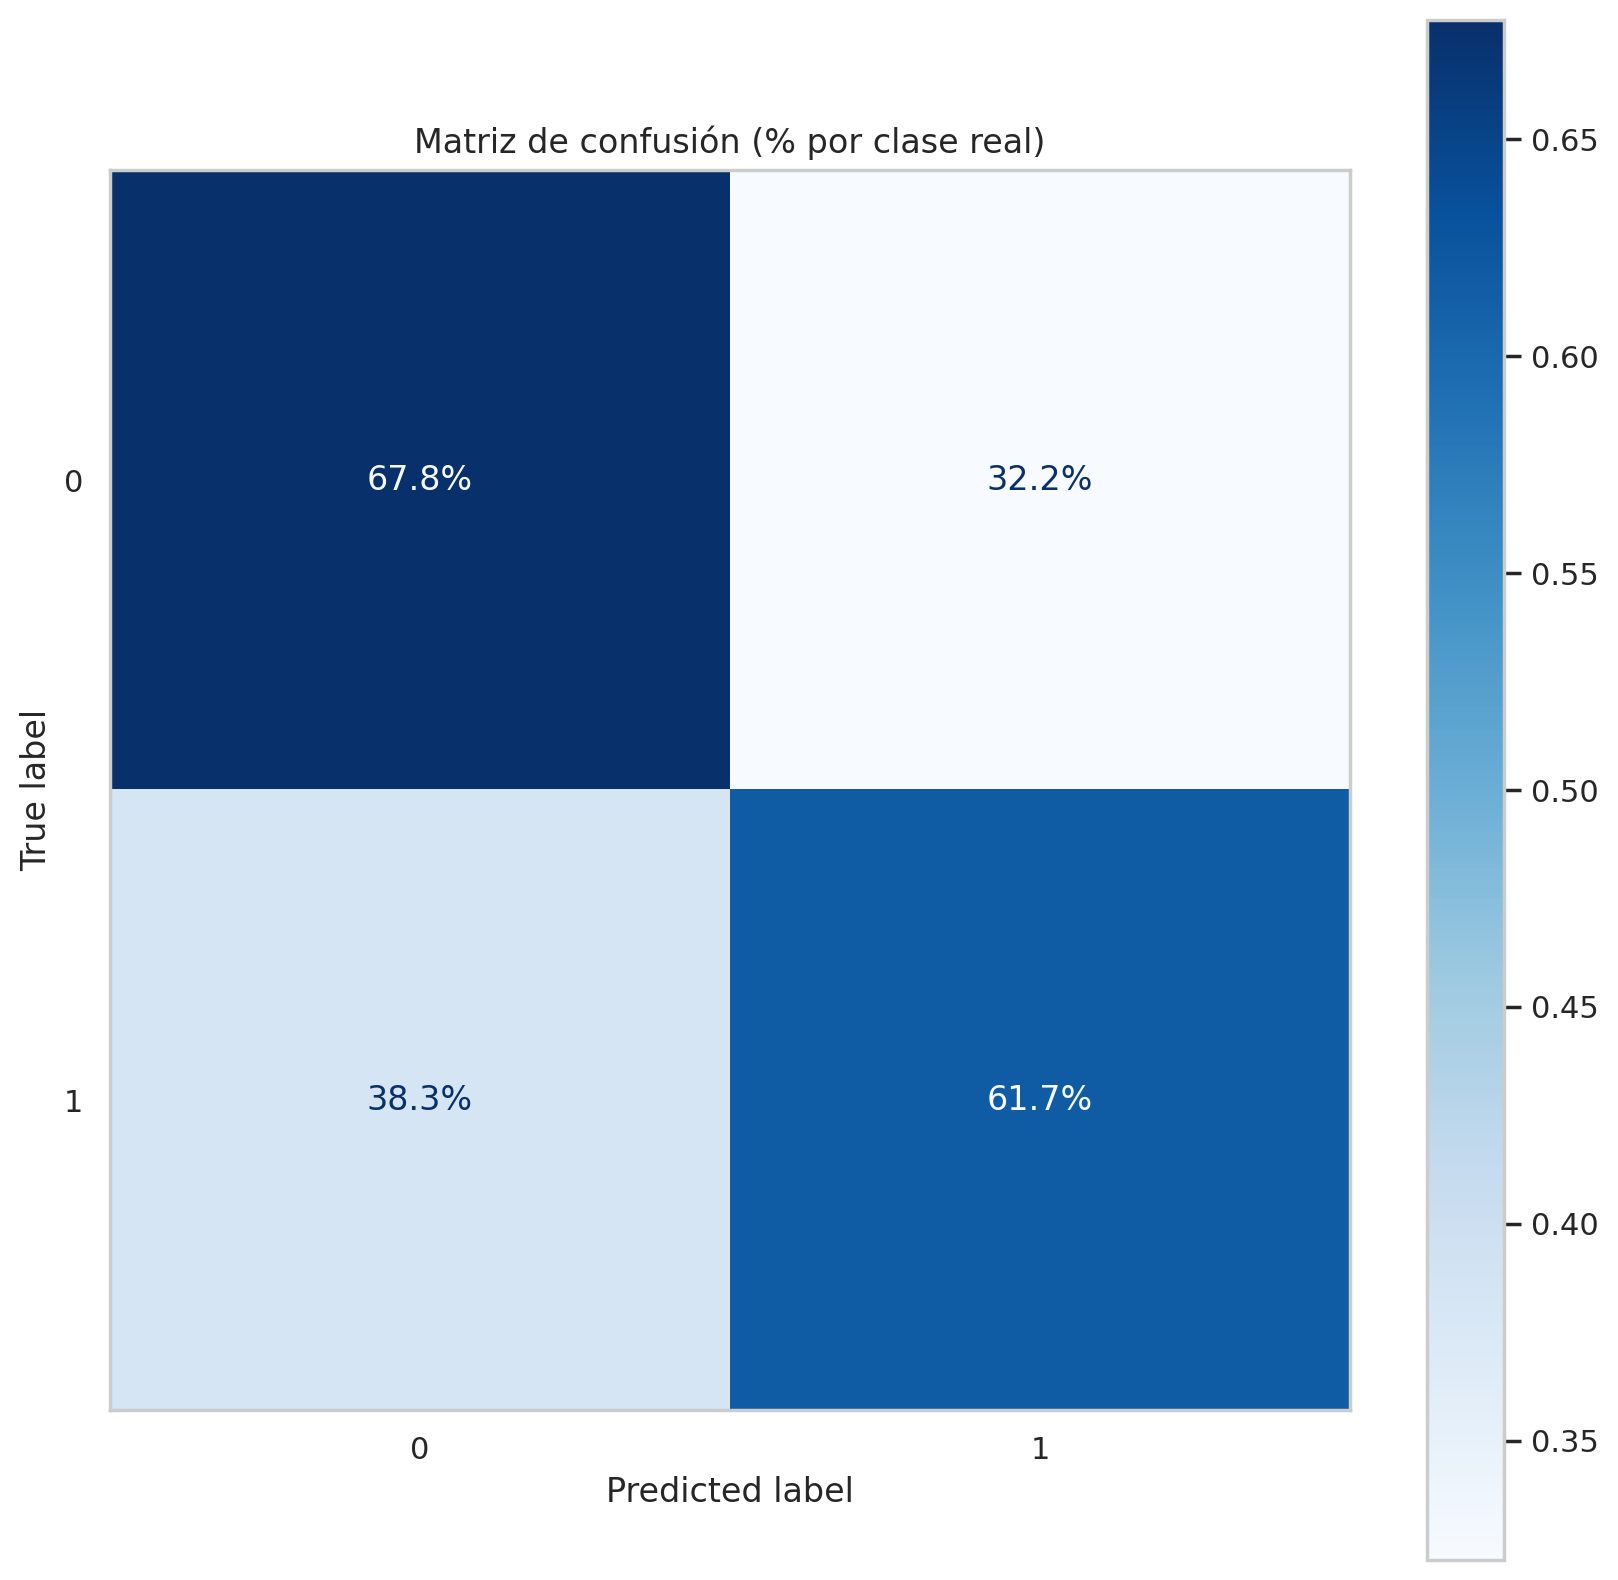

In [41]:
matriz_confusion(qda_smote, xtest, ytest);

El modelo con SMOTe mejroa claramente la probabildaid de clasificar como no potable muestras que originalemente no lo eran (61.7%). Se reduce el porcentaje de clasificación incorrecta apra este grupo al introducir esta técnica de equilibrado. Veasmos que ocurre ahora con NearMiss.

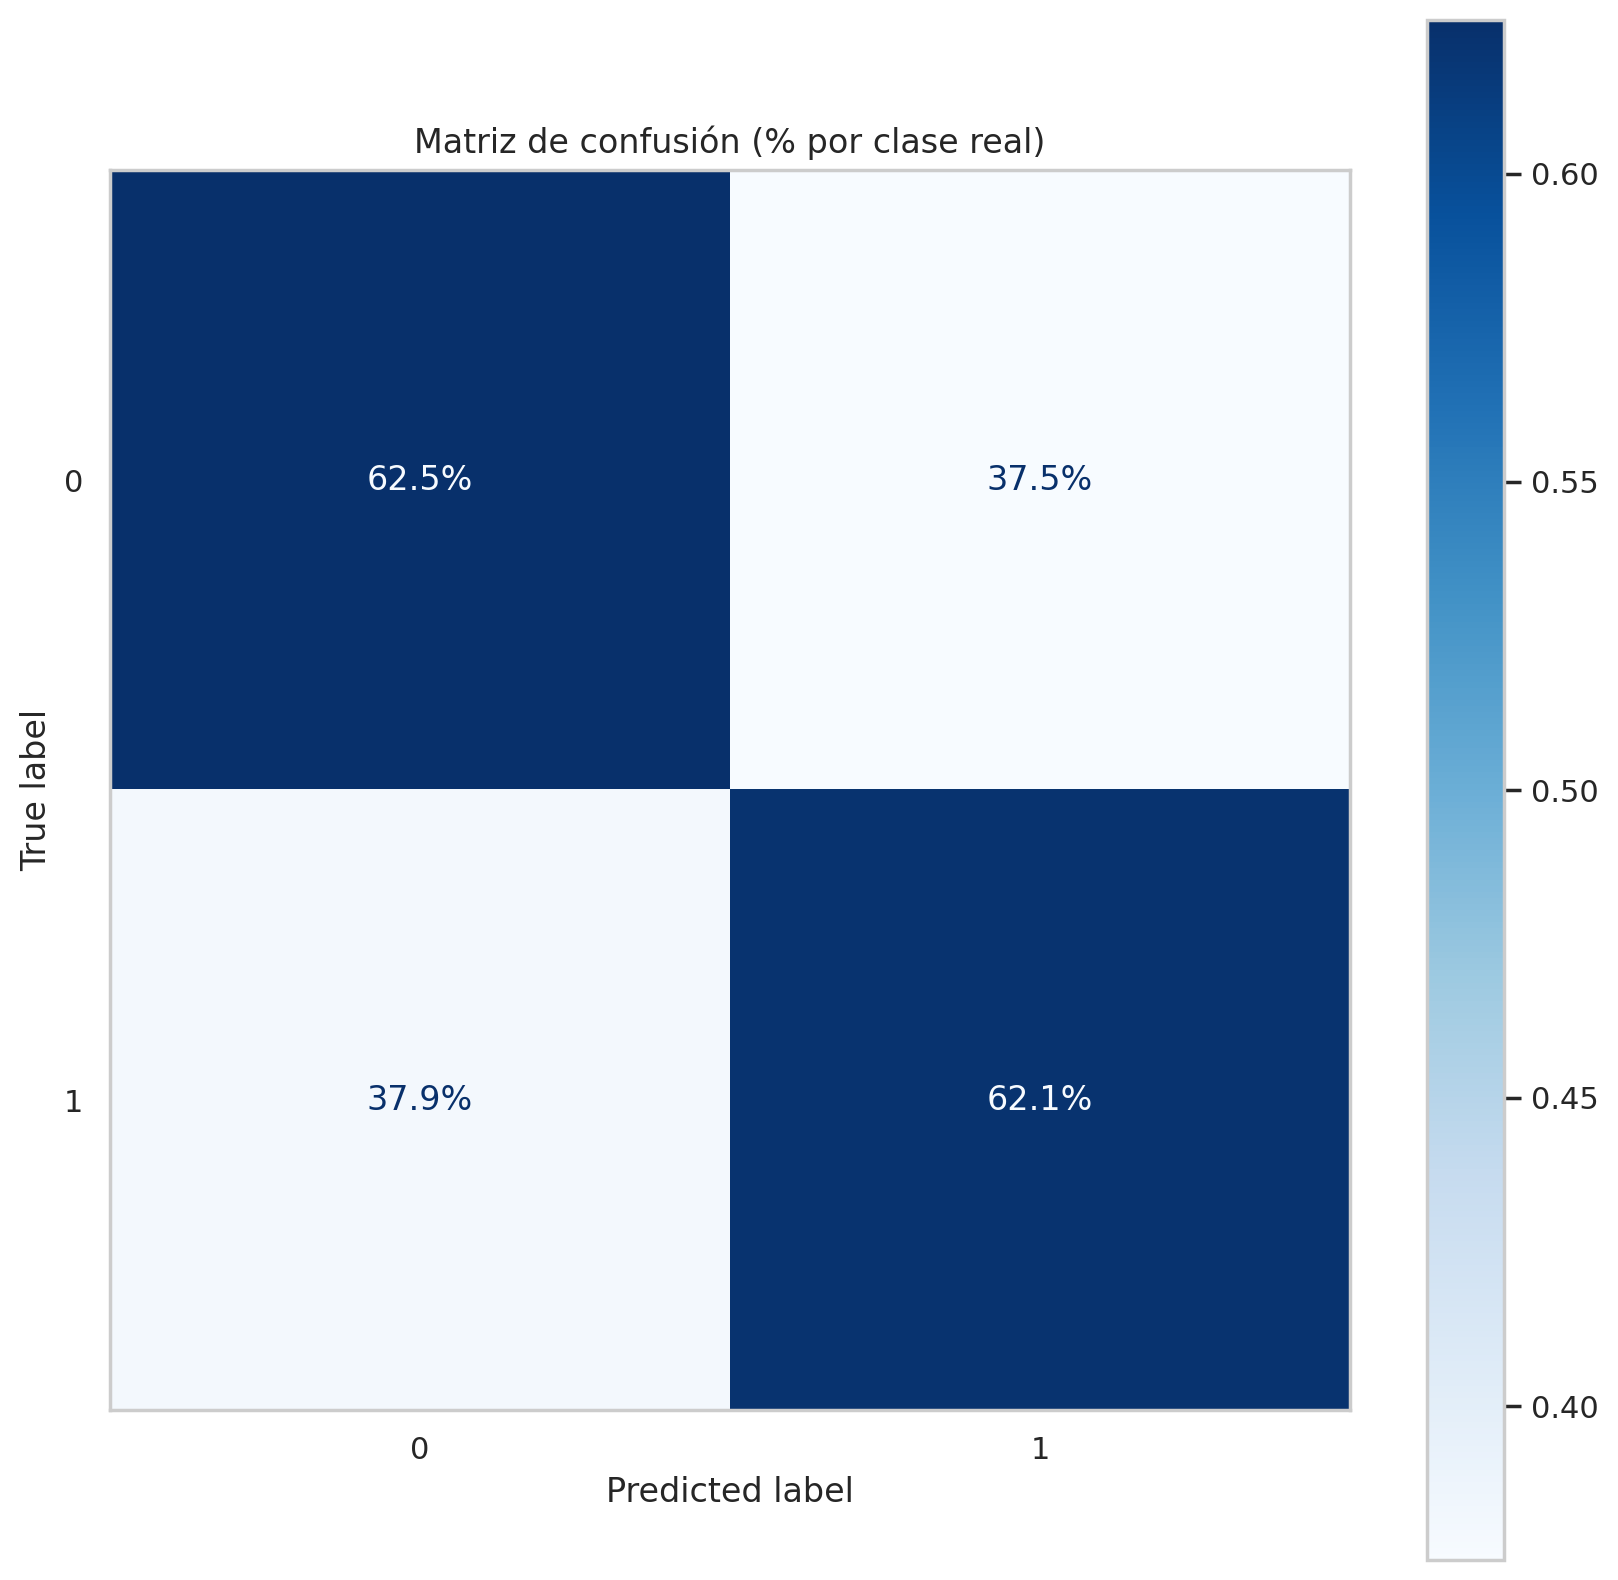

In [42]:
matriz_confusion(qda_nm, xtest, ytest);

Mejoramos levemente los resulatdos dle modelo anterior. No hya cambios significativos con los diferentes técnicas de equilibrado, aunque por supuesto es necesario alguna de ellas para mejorar los resultados del modelo basal (sin considerar equilibrado).

Para finalizar la comparación mostramos una tabla de la métrica recall para los modelos considerados.

In [43]:
# Modelo basal sin equilibrado
qda = QDA().fit(xtrain, ytrain)
# Modelo equilibrado co proporciones iniciales
qda_priors = QDA(priors=prop_ini).fit(xtrain, ytrain)
# Comparación de modelos
resumen = pd.DataFrame({'modelo': ['QDA base', 'Prioris iguales', 'SMOTE', 'NearMiss'],
    'recall_potable': [recall_score(ytest, m.predict(xtest), pos_label=1)
                       for m in [qda, qda_priors, qda_smote, qda_nm]]})
resumen.round(3)

,modelo,recall_potable
0,QDA base,0.387
1,Prioris iguales,0.387
2,SMOTE,0.617
3,NearMiss,0.621


El QDA base ya detecta bastante mejor la clase potable que el LDA (su *recall* parte de ~0.39, frente al ~0.01 del LDA). El **equilibrado** lo eleva aún más (hasta ~0.6 con SMOTE/NearMiss), a costa de bajar la exactitud global: de nuevo, el equilibrado **redistribuye** los aciertos hacia la clase minoritaria, lo deseable cuando esa clase es la importante.



## <font color="steelblue">6.2. Abalones (3 grupos)</font>

Recordatorio del banco: **4.177 abalones** (moluscos marinos) descritos por medidas morfométricas (longitud, diámetro, altura, pesos y anillos≈edad), con target **sexo** (M/F/I), donde **M y F son casi indistinguibles** por tamaño. Veamos si el QDA mejora aquí.

In [44]:
# Carga y preprocesado
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/abalone_clean.csv'
abalone = pd.read_csv(url, index_col=0); abalone['Sex'] = abalone['Sex'].astype('category')
strain_raw, stest_raw = split_sample(abalone, 'Sex', 0.3, 42, True)
strain, prep = preprocesar_datos(strain_raw, 'Sex')
stest,  _    = preprocesar_datos(stest_raw,  'Sex', prep)
xtrain, ytrain = strain.drop('Sex', axis=1), strain['Sex']
xtest,  ytest  = stest.drop('Sex', axis=1),  stest['Sex']

# Frecuencias iniciales en la muestra de entrenamiento
prop_ini = list(ytrain.value_counts()/len(ytrain))

lda = LDA(priors=prop_ini).fit(xtrain, ytrain)
qda = QDA(priors=prop_ini).fit(xtrain, ytrain)
# Validación de ambos modelos
print('LDA CV:'); val_lda = validar_modelo(lda, xtrain, ytrain, 'accuracy', 10)
print('\nQDA CV:'); val_qda = validar_modelo(qda, xtrain, ytrain, 'accuracy', 10)

Estratificando por 'Sex'.
  Entrenamiento: 2923 muestras | Test: 1254 muestras
LDA CV:
Validacion cruzada (10 folds, score=accuracy): media = 0.525 +/- 0.025

QDA CV:
Validacion cruzada (10 folds, score=accuracy): media = 0.523 +/- 0.023


— Matriz de confusión QDA —


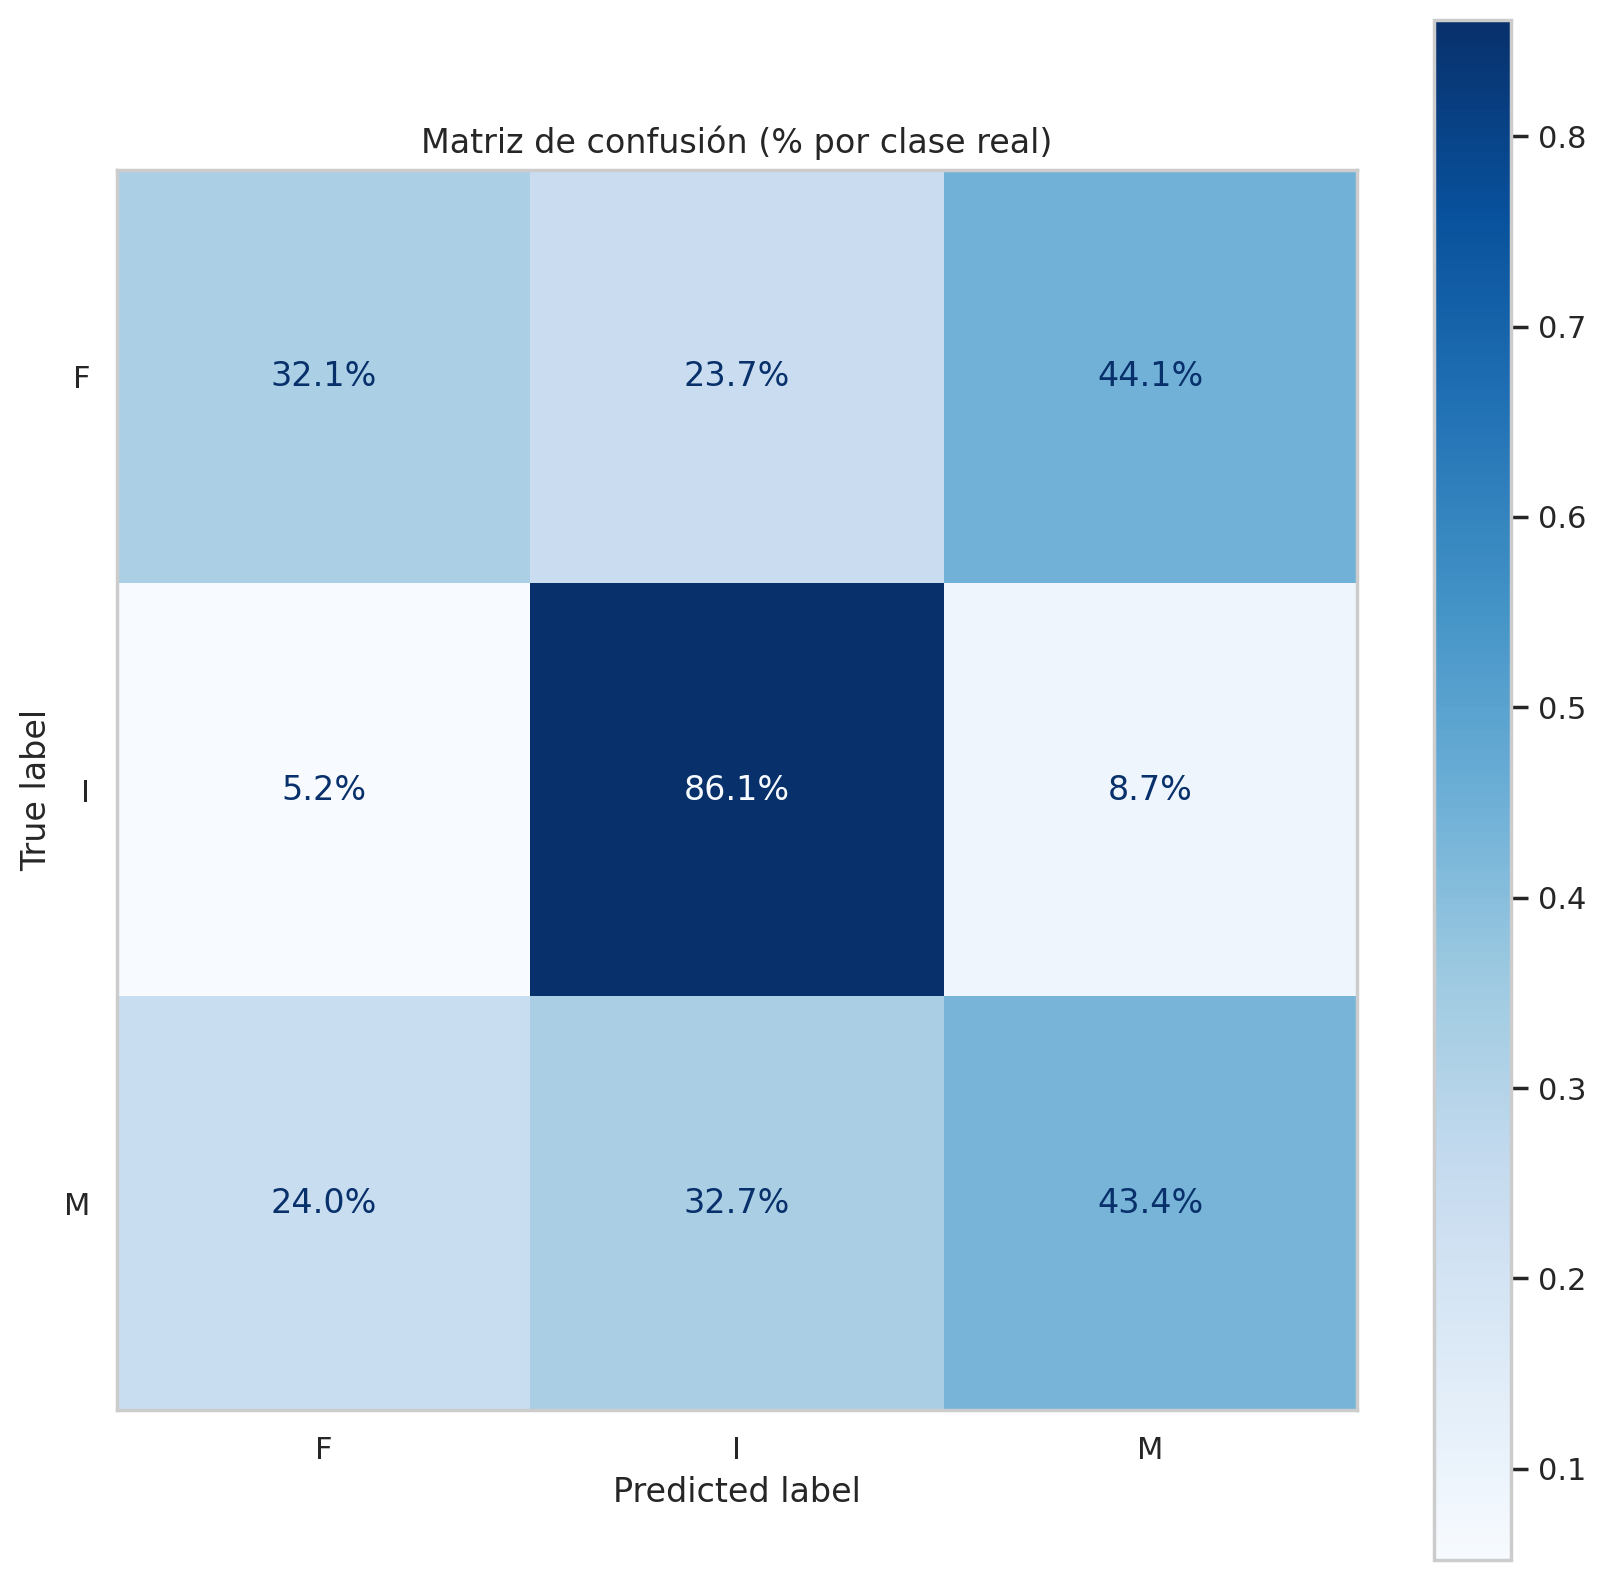

In [45]:
print('— Matriz de confusión QDA —'); matriz_confusion(qda, xtest, ytest);

Aquí el QDA **no mejora**. La razón es que la dificultad no está en la **forma** de las fronteras sino en que **M y F se solapan** intrínsecamente; añadir flexibilidad solo aporta varianza sin reducir esa confusión. Es un recordatorio importante: **un modelo más complejo no es siempre mejor**. Lo confirmamos con la selección de variables y las regiones.

Dos variables más relevantes (ANOVA F): ['Diameter', 'Whole weight']
Códigos de clase: {0: 'F', 1: 'I', 2: 'M'}


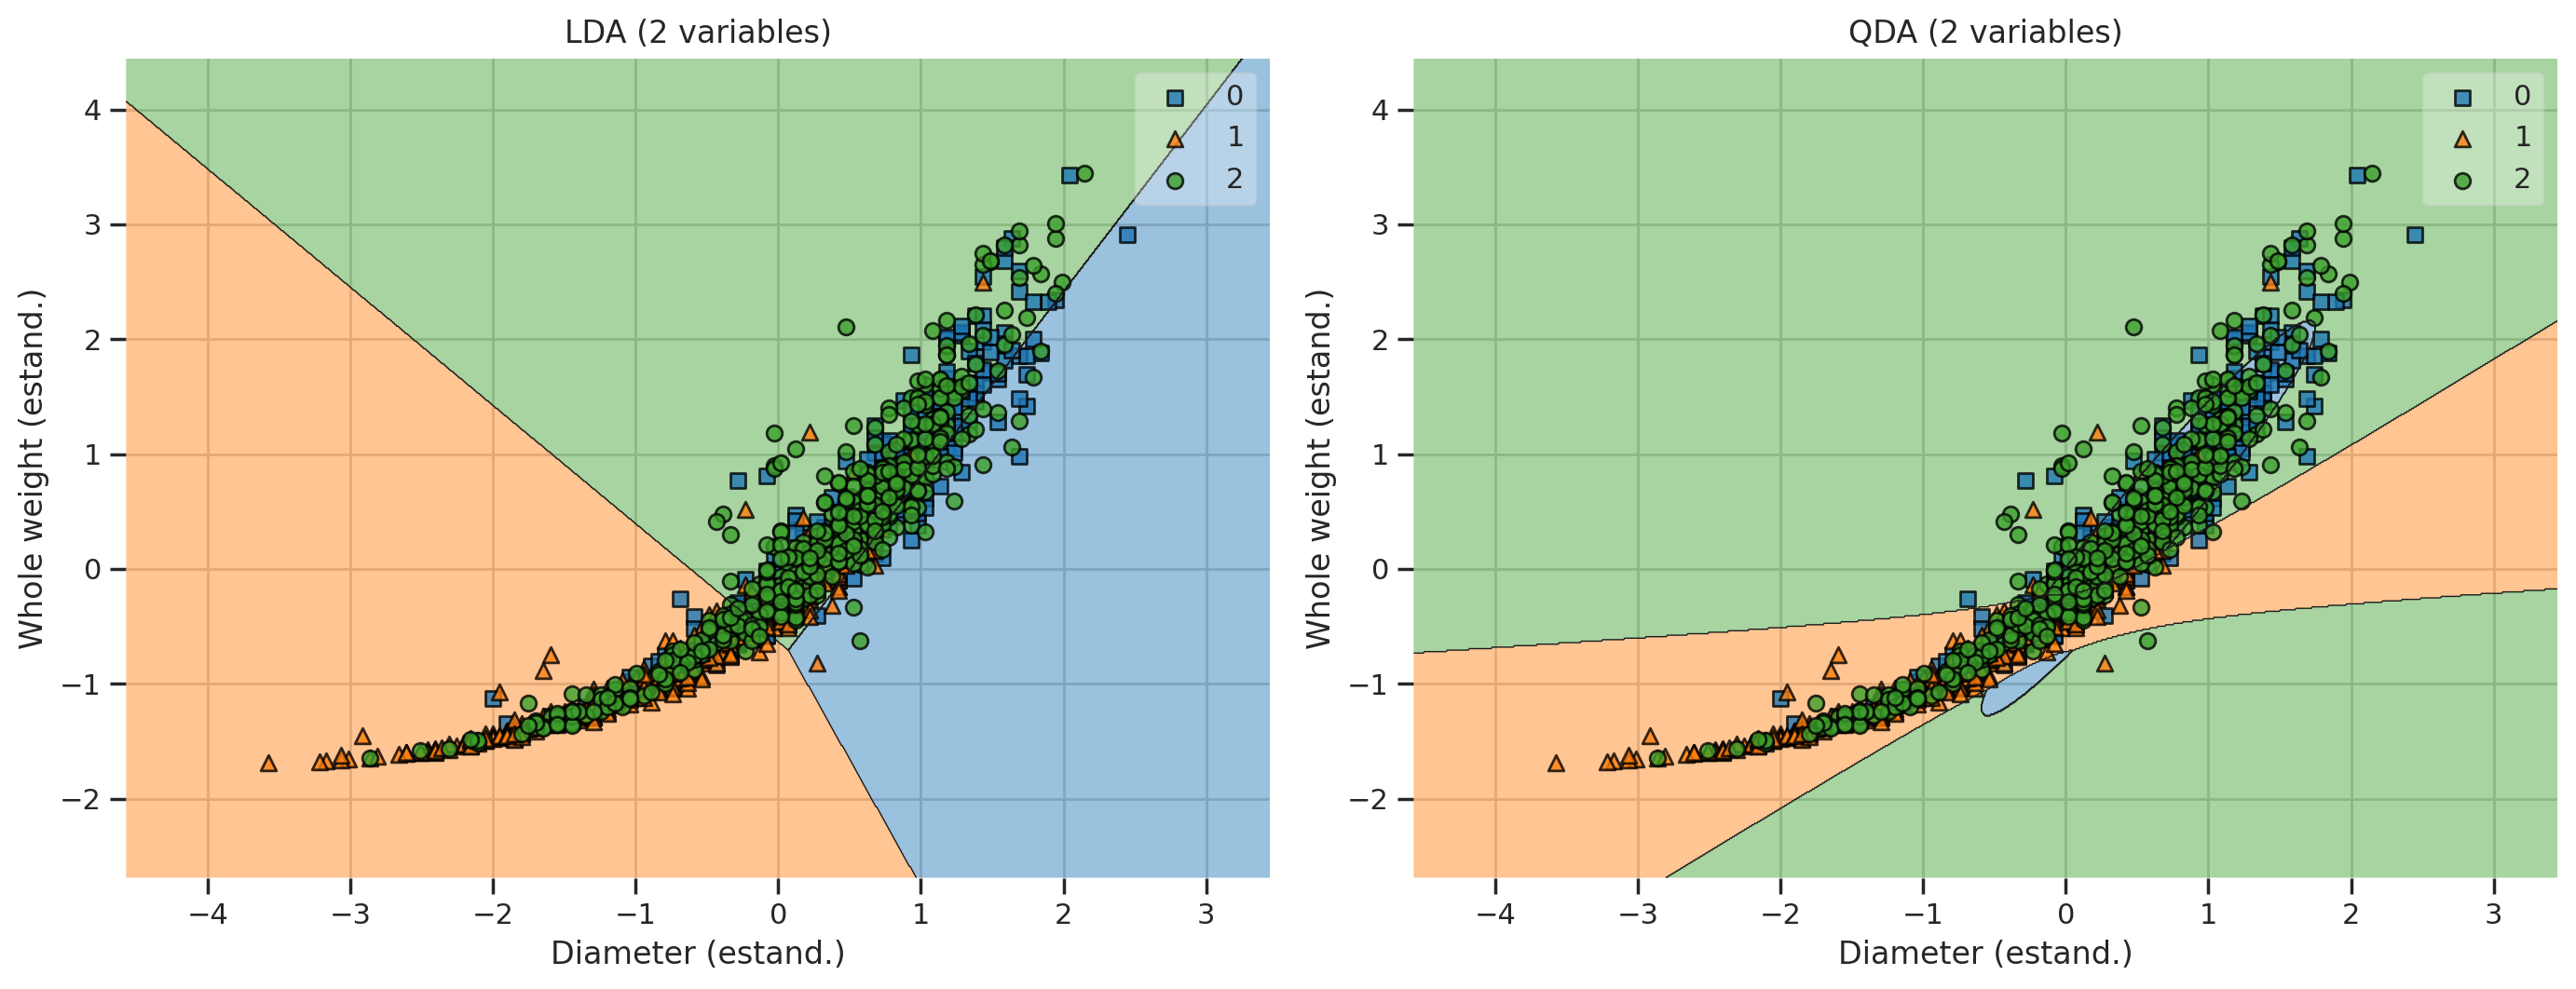

In [46]:
F, _ = f_classif(xtrain, ytrain)
ranking = pd.Series(F, index=xtrain.columns).sort_values(ascending=False)
top2 = ranking.index[:2].tolist(); print('Dos variables más relevantes (ANOVA F):', top2)
codigos = dict(enumerate(ytrain.cat.categories)); print('Códigos de clase:', codigos)
lda2 = LDA().fit(xtrain[top2], ytrain.cat.codes); qda2 = QDA().fit(xtrain[top2], ytrain.cat.codes)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
plot_decision_regions(X=xtest[top2].values, y=ytest.cat.codes.values, clf=lda2, ax=ax[0]); ax[0].set_title('LDA (2 variables)')
plot_decision_regions(X=xtest[top2].values, y=ytest.cat.codes.values, clf=qda2, ax=ax[1]); ax[1].set_title('QDA (2 variables)')
for a in ax: a.set_xlabel(top2[0] + ' (estand.)'); a.set_ylabel(top2[1] + ' (estand.)')
plt.tight_layout(); plt.show()

En el mapa se ve que **I** (juveniles, código según `codigos`) se separa con relativa claridad, pero **M y F** ocupan la **misma zona**: ni la recta del LDA ni la curva del QDA pueden separarlas, porque físicamente se parecen. De ahí que la flexibilidad extra del QDA no ayude.




# <font color="steelblue">7. Regularización y optimización de hiperparámetros (RDA)</font>

El **análisis discriminante regularizado** consiste en **buscar el punto óptimo del dial** de regularización por validación cruzada: la **`shrinkage`** del LDA (caso lineal, RDA-lineal) y el **`reg_param`** del QDA (caso cuadrático, RDA-cuadrático). Lo hacemos con `GridSearchCV` en **los dos** conjuntos reales y comparamos los cuatro modelos.

## <font color="steelblue">7.1. *Water potability*</font>

Comenzamos con el ejemplo de potabildiad del agua. Planteamos un grid de búsqueda para optimizar el modelo.

In [47]:
# Preprocesar datos
strain_raw, stest_raw = split_sample(water, 'Potability', 0.2, 123, True)
strain, prep = preprocesar_datos(strain_raw, 'Potability'); stest, _ = preprocesar_datos(stest_raw, 'Potability', prep)
xtr_w, ytr_w = strain.drop('Potability', axis=1), strain['Potability']
xte_w, yte_w = stest.drop('Potability', axis=1),  stest['Potability']

Estratificando por 'Potability'.
  Entrenamiento: 2620 muestras | Test: 656 muestras


Generamos el grid de búsqueda y optimizamos

In [52]:
prop_ini_water = list(ytr_w.value_counts(normalize=True).sort_index())

# RDA-lineal: optimizamos shrinkage del LDA
gs_lin = GridSearchCV(LDA(priors=prop_ini_water, solver='eigen'), {'shrinkage': [None, 'auto', 0.1, 0.3, 0.5, 0.7, 0.9]},
                      scoring='f1_weighted', cv=10).fit(xtr_w, ytr_w)
# RDA-cuadrático: optimizamos reg_param del QDA
gs_cuad = GridSearchCV(QDA(priors=prop_ini_water), {'reg_param': np.arange(0, 1, 0.1)},
                       scoring='f1_weighted', cv=10).fit(xtr_w, ytr_w)
# Parámetros optimizados
print('RDA-lineal  mejor shrinkage:', gs_lin.best_params_, '| f1w CV:', round(gs_lin.best_score_, 3))
print('RDA-cuad    mejor reg_param:', gs_cuad.best_params_, '| f1w CV:', round(gs_cuad.best_score_, 3))
# Tabla de resumen
print("\nTabla comparativa")
resumen_w = pd.DataFrame({'modelo': ['LDA', 'QDA', 'RDA-lineal', 'RDA-cuadrático'],
    'f1w_test': [f1_score(yte_w, m.fit(xtr_w, ytr_w).predict(xte_w), average='weighted')
                 for m in [LDA(priors=prop_ini_water), QDA(priors=prop_ini_water), gs_lin.best_estimator_, gs_cuad.best_estimator_]]})
resumen_w.round(3)

RDA-lineal  mejor shrinkage: {'shrinkage': 0.5} | f1w CV: 0.47
RDA-cuad    mejor reg_param: {'reg_param': np.float64(0.0)} | f1w CV: 0.629

Tabla comparativa


,modelo,f1w_test
0,LDA,0.472
1,QDA,0.676
2,RDA-lineal,0.469
3,RDA-cuadrático,0.676


¿Cómo interpretamos dicha tabla?

## <font color="steelblue">4.2. *Abalone*</font>

Evaluamos ahora el segundo ejemplo.

In [54]:
# Preprocesado
strain_raw, stest_raw = split_sample(abalone, 'Sex', 0.3, 42, True)
strain, prep = preprocesar_datos(strain_raw, 'Sex'); stest, _ = preprocesar_datos(stest_raw, 'Sex', prep)
xtr_a, ytr_a = strain.drop('Sex', axis=1), strain['Sex']
xte_a, yte_a = stest.drop('Sex', axis=1),  stest['Sex']
# Optimización
prop_ini_abalone = list(ytr_a.value_counts(normalize=True).sort_index())

gs_lin_a = GridSearchCV(LDA(priors=prop_ini_abalone, solver='eigen'), {'shrinkage': [None, 'auto', 0.1, 0.3, 0.5, 0.7, 0.9]}, scoring='accuracy', cv=5).fit(xtr_a, ytr_a)
gs_cuad_a = GridSearchCV(QDA(priors=prop_ini_abalone), {'reg_param': np.arange(0, 1, 0.1)}, scoring='accuracy', cv=5).fit(xtr_a, ytr_a)
print('RDA-lineal  mejor shrinkage:', gs_lin_a.best_params_, '| acc CV:', round(gs_lin_a.best_score_, 3))
print('RDA-cuad    mejor reg_param:', gs_cuad_a.best_params_, '| acc CV:', round(gs_cuad_a.best_score_, 3))
# Tabla de resumen
print("\nTabla comparativa")
resumen_a = pd.DataFrame({'modelo': ['LDA', 'QDA', 'RDA-lineal', 'RDA-cuadrático'],
    'f1w_test': [f1_score(yte_a, m.fit(xtr_a, ytr_a).predict(xte_a), average='weighted')
                 for m in [LDA(priors=prop_ini_abalone), QDA(priors=prop_ini_abalone), gs_lin_a.best_estimator_, gs_cuad_a.best_estimator_]]})
resumen_a.round(3)

Estratificando por 'Sex'.
  Entrenamiento: 2923 muestras | Test: 1254 muestras
RDA-lineal  mejor shrinkage: {'shrinkage': None} | acc CV: 0.544
RDA-cuad    mejor reg_param: {'reg_param': np.float64(0.30000000000000004)} | acc CV: 0.545

Tabla comparativa


,modelo,f1w_test
0,LDA,0.545
1,QDA,0.502
2,RDA-lineal,0.545
3,RDA-cuadrático,0.455


Las tablas resumen la comparación de los cuatro modelos. En **water**, los modelos **cuadráticos** (QDA y RDA-cuadrático) son claramente superiores: la regularización del reg_param afina algo más el QDA. En **abalone**, en cambio, los modelos **lineales** (LDA y RDA-lineal) son ligeramente mejores, porque la flexibilidad cuadrática no aporta y sí añade varianza. La moraleja general del cuaderno: la **regularización** permite encontrar el equilibrio entre rigidez (LDA) y flexibilidad (QDA), y la **validación cruzada** es la que decide cuál conviene en cada problema —no hay un ganador universal—.



# <font color="steelblue">8. Referencias</font>

* Hastie, Tibshirani & Friedman (2009). *The Elements of Statistical Learning* (cap. 4). Springer.
* James, Witten, Hastie & Tibshirani (2021). *An Introduction to Statistical Learning* (cap. 4).
* Friedman, J. (1989). *Regularized Discriminant Analysis*. JASA.
* Rencher, A. C. (2003). *Methods of Multivariate Analysis*. Wiley.
* scikit-learn — *Linear and Quadratic Discriminant Analysis*: https://scikit-learn.org/stable/modules/lda_qda.html